# AI ANALYST LAB

![](../_img/ai_analyst_lab.png)

### A Hands-on Course on AI for Data Analysts
## Review 02: Probability and Statistics

Feedback should be sent to [goran.milovanovic@datakolektiv.com](mailto:goran.milovanovic@datakolektiv.com).

This is a **review notebook**. It steps back from the business-analytics thread to consolidate the **probability and statistics foundations** that quietly underpin everything you have done so far: the distributions behind Sessions 01–03, and the sampling logic behind every average, confidence interval, and p-value you have reported. Nothing here is new in spirit — it is the careful, from-first-principles version of ideas the sessions used at speed.

***
### What we will do today

We rebuild probability from the ground up and end at the one theorem that makes statistical inference possible. We move in three movements:

1. **Discrete probability** (R2.1–R2.5) — experimental vs. theoretical probability, the $\sigma$-algebra of events and the Kolmogorov axioms, discrete random variables, and the workhorse discrete distributions (Bernoulli, Binomial, Geometric, Discrete Uniform, Poisson) — each simulated with NumPy and cross-checked with SciPy.
2. **Continuous probability** (R2.6–R2.8) — continuous random variables, where probability is *area under a curve*; the Uniform, Exponential, and Normal distributions; and the definitions of mathematical expectation and variance.
3. **From samples to inference** (R2.9–R2.10) — the sampling distribution of the mean and the **Central Limit Theorem**: why the average of a sample behaves so predictably, and why that single fact underwrites every confidence interval in this course.

Throughout, the method is the one this course always insists on: **simulate first to build intuition, then confirm with the closed-form formula.** Every number is computed, never asserted.

## R2.1 Event and Experimental Probability

When asked: *What's the probability of landing Tails when tossing a (fair) coin?* You'd (probably) answer: $\frac{1}{2}$. Or 50%. But what does that mean?

And when asked: *What's the probability of getting 6 when rolling a six-sided (fair) die?* The expected answer: $\frac{1}{6}$. *What about NOT getting 6?* It's: $\frac{5}{6}$. And *getting a number less than five?* $\frac{2}{3}$? But what do those numbers mean?

And and - *The probability of drawing an Ace from a (fair) deck of cards?*

---

Let's get back to the coin. $\frac{1}{2}$ says you. But what does it mean? Maybe you ment that out of two tossings you'll land exactly one Tails ($TH$ or $HT$)? Okay, let's toss a coin two times. I got $TT$. Maybe my assumption was wrong? Or I've just got unlucky? Let's toss it again. $HT$ this time. Maybe I'm actually right? Or I got lucky. Another two tosses! $HH$. Hmm... Unlucky again? But can I talk about luck in mathematics and in hypothesis testing?

What about the other answer: 50%. Does that mean that I'll land Tails exactly half the times when tossing a coin $N$ times? Let's toss it, say, 10 times. But I don't actually have a coin. Luckily I have Python which can simulate tossing a coin. 

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(seed=1023)

In [2]:
coin = ['H', 'T']

tossing = rng.choice(coin, size=10)
tossing

array(['H', 'H', 'T', 'T', 'T', 'T', 'H', 'T', 'H', 'T'], dtype='<U1')

6 of 10 Tails. Close, but not quite 50%. But, wait. 50% also means 50/100. Let's toss a coin 100 times then. 

In [3]:
tossing = rng.choice(coin, size=100)
tossing

array(['T', 'H', 'H', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'H', 'T',
       'H', 'T', 'H', 'H', 'H', 'T', 'T', 'H', 'T', 'H', 'H', 'H', 'H',
       'T', 'H', 'H', 'T', 'H', 'H', 'T', 'T', 'H', 'H', 'H', 'T', 'H',
       'T', 'H', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'H',
       'H', 'H', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'H', 'T', 'H', 'T',
       'T', 'T', 'T', 'H', 'H', 'H', 'H', 'H', 'H', 'T', 'H', 'H', 'H',
       'T', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'H', 'T', 'T',
       'H', 'T', 'H', 'T', 'T', 'T', 'H', 'H', 'H'], dtype='<U1')

How many Tails, then?

In [4]:
np.unique(tossing, return_counts=True)

(array(['H', 'T'], dtype='<U1'), array([53, 47]))

47/100. Not bad. But not quite 50%. Lucky, but not as quite? (But can I talk about luck in mathematics and in hypothesis testing?) What if those 50% is actually an *approximation* of the result? Let's toss a coin 1000 times.  

In [5]:
tossing = rng.choice(coin, size=1000)
np.unique(tossing, return_counts=True)

(array(['H', 'T'], dtype='<U1'), array([480, 520]))

520/1000. That's 52%. And that's not that quite bad *approximation*. But still... Now, let's toss a coin ONE MILLION TIMES.

In [6]:
tossing = rng.choice(coin, size=10**6)
np.unique(tossing, return_counts=True)

(array(['H', 'T'], dtype='<U1'), array([500537, 499463]))

In [7]:
499463/10**6

0.499463

Well - that's 49.95%, almost 50%. Quite good approximation. 

What if tossed a coin more than million times?

In [8]:
tossing = rng.choice(coin, size=10**7)
np.unique(tossing, return_counts=True)

(array(['H', 'T'], dtype='<U1'), array([4999908, 5000092]))

In [9]:
5000092/10**7

0.5000092

This is even better, veeeery close to 50%; 50.001%, to be more exact.

And if we tossed a coin **infinitely many times**? Then there is no approximation. We'd get 50% sharp. Mathematically, we can write this

$$ P(T) = \lim_{N_{\rm TRIES}\rightarrow\infty}\frac{n_{\rm HITS}}{N_{\rm TRIES}} = 0.5 = \frac{1}{2}.$$

What are all these letters? Let's interpret this formula one by one. 

- $T$ is the *event*: event of landing Tails when tossing ONE coin. 


- $P$ is the *probability*: we may consider it as a function which *measures* how probable an event is. So, $P(T)$ is probability of langing Tails when tossing one coin. 


- $N_{\rm TRIES}$ is the number of trials of the SAME experiment. In our case, it's the number of tossing a coin. 


- $n_{\rm HITS}$ is the number of 'hits', i.e. the number of desired outcomes in our set of trials. In our case, it's the number of Tails landed. 


- $\lim_{N_{\rm TRIES}\rightarrow\infty}$ is the *limit*: a value of the fraction $\frac{n_{\rm HITS}}{N_{\rm TRIES}}$ which we would obtain if we would *theoretically* be able to toss a coin infinitely many times in our finite lives. But we can't do that. We can only obtain an *experimental* (or *statistical*) approximation of the *theoretical* value in finite number of trials. And as we demonstrated - the larger number of trials, the better the approximation. 

***

Let's now illustrate this *limit* on another example: rolling a six-sided die. Intuintively we say that the probability of getting a 6 is $\frac{1}{6}$, or 16.666...% . Similarly as with the coin, we'll simulate rolling a die for various numbers of trials and list the results, i.e. approximations of theoretical probability.

In [10]:
exp_prob_df = pd.DataFrame(columns=['No. of Rolls', 'No. of 6s', 'Experimental Probability'])

number_of_rolls = np.logspace(1.75, 7, 100, dtype=int).tolist()
number_of_6s = []
die = list(range(1, 7))
           
for n_rolls in number_of_rolls:
    rolling = rng.choice(die, size=n_rolls)
    
    results = np.unique(rolling, return_counts=True)
    n_6 = results[1][-1]
    number_of_6s.append(n_6)

number_of_6s = np.asarray(number_of_6s)

exp_prob_df['No. of Rolls'] = number_of_rolls
exp_prob_df['No. of 6s'] = number_of_6s
exp_prob_df['Experimental Probability'] = np.round(number_of_6s/number_of_rolls, 5)
    
    
print(exp_prob_df.to_string())

    No. of Rolls  No. of 6s  Experimental Probability
0             56          6                   0.10714
1             63         22                   0.34921
2             71         12                   0.16901
3             81         16                   0.19753
4             91         12                   0.13187
5            103         20                   0.19417
6            116         14                   0.12069
7            132         23                   0.17424
8            149         26                   0.17450
9            168         31                   0.18452
10           190         36                   0.18947
11           215         32                   0.14884
12           243         35                   0.14403
13           275         50                   0.18182
14           310         59                   0.19032
15           351         60                   0.17094
16           396         75                   0.18939
17           448         78 

And here's how our limit looks like:

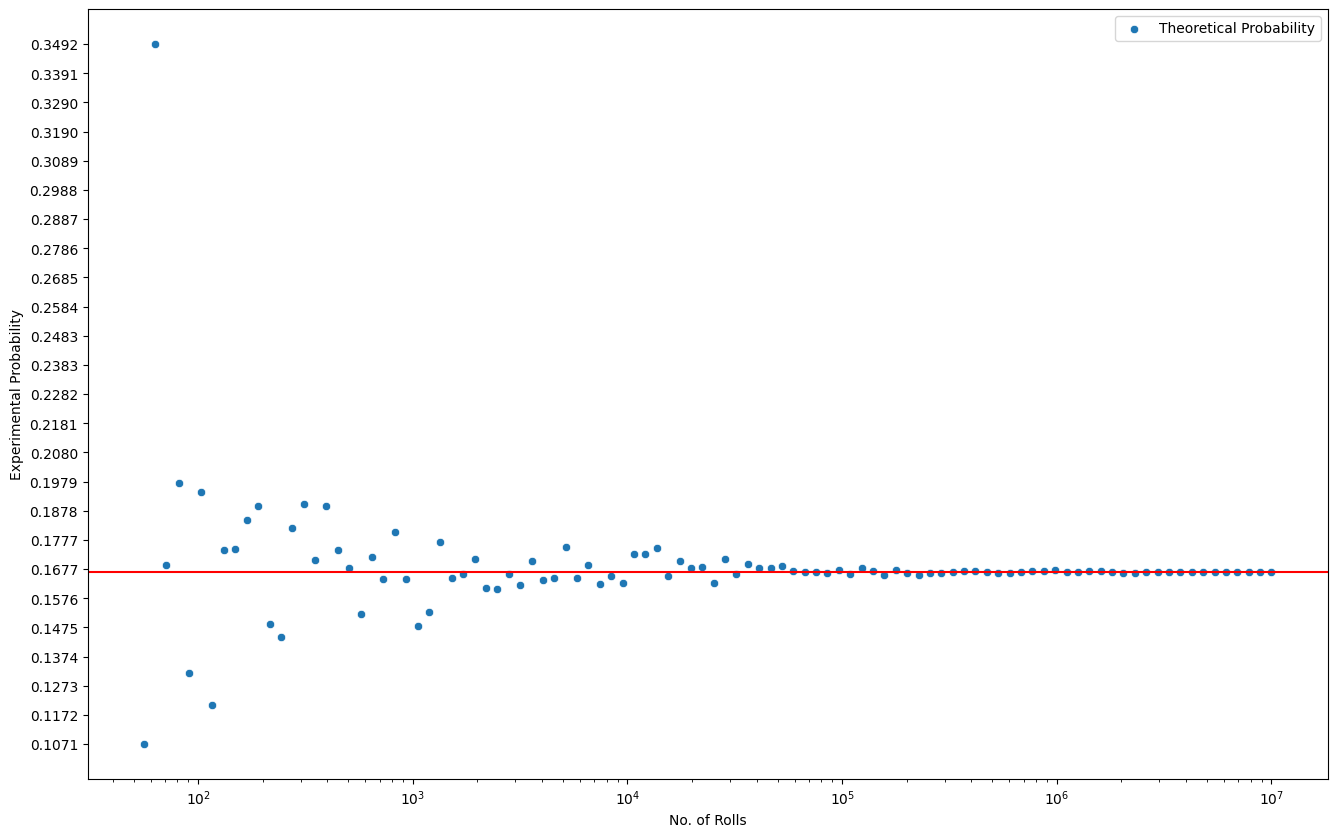

In [11]:
fig, ax = plt.subplots(figsize=(16, 10))

sns.scatterplot(ax = ax, data = exp_prob_df, x='No. of Rolls', y='Experimental Probability');
ax.axhline(.16667, c='r')

ax.set_xscale('log')
ax.set_yticks(np.linspace(exp_prob_df['Experimental Probability'].min(), exp_prob_df['Experimental Probability'].max(), 25))
ax.legend(['Theoretical Probability']);

From the scatterplot above we see how the values of ratio $\frac{n_{\rm HITS}}{N_{\rm TRIES}}$ converge towards the predicted theoretical probability of 16.666...% as $N_{\rm TRIES}\rightarrow\infty$.

But, is there a way to calculate theoretical probability **exactly**?

## R2.2 $\sigma$-Algebra of Events and Theoretical Probability

In order to be able to speak properly about theoretical probability (and be able to compute it), we need to introduce *$\sigma$-algebra of events* and *probability-as-a-measure*. We can consider $\sigma$-algebra of events as a family of sets where every set is an event, and every element of this event-set is an *outcome* for which consider the evenet realized, i.e. a *favorable outcome*. 

For example, if we toss a coin two times, then one event-set might be

$$ A - {\rm Landed\ 1\ Heads\ and\ 1\ Tails}, $$

and its elements are

$$ A = \{HT, TH\}.$$

A set of all the possible outcomes for a given experiment/observation is called the *universal set*. It is denoted by $\Omega$ and it is the set upon which $\sigma$-algebra of events is built upon, from the subsets $A\subset\Omega$ of the universal set.  

For tossing a coin two times we have

$$ \Omega = \{HH, HT, TH, TT\},$$

and obviously

$$ A \subset \Omega. $$

Let $\Sigma$ be a $\sigma$-algebra of events on $\Omega$, and $A$ and $B$ two events (which we write $A, B\in \Sigma$). Then we have:

$$1^\circ\quad \emptyset,\ \Omega \in \Sigma$$

$$2^\circ\quad A^C \in \Sigma$$

$$3^\circ\quad A\cup B \in \Sigma$$

$$4^\circ\quad A\cap B \in \Sigma.$$

What do these cryptic messages even mean? Let's explain them one by one, I promise they make sense.

$$1^\circ\quad \emptyset,\ \Omega \in \Sigma$$

This means that the empty set $\emptyset$ and the total set $\Omega$ are also considered as events.

$\emptyset$ is called an *impossible event*, and it does not contain any (possible) outcome. 

$\Omega$, viewed as an event is called *certain event* - getting any outcome from all the possible outcomes is definitely a certain event. 

---

$$2^\circ\quad A^C \in \Sigma$$

An complementary set of $A$: $A^C = \Omega\setminus A$ is also considered as an event. Every unfavourable outcome of $A$ is favourable for $A^C$ (and vice versa). So, for the event $A$ as defined above, we have:

$$ A^C = \{HH, TT\}. $$

---

$$3^\circ\quad A\cup B \in \Sigma$$

A union of two events (denoted also as $A + B$) is also considered as an event. But what is a union of two events actually? We say that the event $A\cup B$ is realized when at least one of the events $A$ **OR** $B$ is realized. $A\cup B$ contains all the outcomes which are favourable for either the event $A$ **OR** event $B$.

For example, if we define event $B$ as

$$B - {\rm Landed\ 2\ Tails,}$$

we have 

$$ A\cup B = \{HT, TH, TT\}.$$

---

$$4^\circ\quad A\cap B \in \Sigma.$$

An intersection of two events (denoted also as AB) is also considered as an event. We say that the event $AB$ is realized when both events $A$ **AND** $B$ are simultaneously realized. $AB$ contains all the outcomes which are favourable for both events $A$ **AND** $B$. 

For examle, if we define event $C$ as 

$$ C - {\rm Tails\ in\ the\ first\ coin\ toss}, $$

we have 

$$ AC = \{HT, TH\} \cap \{TH, TT\} = \{TH\}.$$

Two events $A$ and $B$ are *mutually exclusive* or *disjoint* if $A\cap B = \emptyset$, i.e. if realization of both events simultaneously is an impossible event.

Two events $A$ and $B$ are *independant* if the outcome of one event does not influence the outcome of the other. For example, when tossing a coin two times, the result of the first toss does not influence the outcome of the second.

---

One more importan notion is the *elementary event* - an event containing a single possible outcome. So, for tossing our coin two times, elementary events are: $\{HH\},\ \{HT\},\ \{TH\}$ and $\{TT\}$.

$\sigma$-algebras of events serve us as a brige between the natural language by which we describe events and their outcomes with formal mathematical language to describe them via sets, their elements and set operations. The upside of mathematical objects is that it is natural to impose some measure on them, and now we can measure the events, i.e. measure the probability of event realization. So we can define probability-as-a-measure, that is a mapping $P$ from $\sigma$-algebra of events to interval a set of real numbers via following set of *axioms* (known as *Kolmogorov Axioms*):

**Axiom 1**: For any event $A$ we have

$$ P(A)\geqslant 0.$$

**Axiom 2**: For certain event $\Omega$ we have

$$ P(\Omega) = 1.$$

**Axiom 3**: For mutually exclusive events $A_1, A_2, \ldots, A_n, \ldots$ we have

$$P\Big(\bigcup_{i=1}^{\infty}A_i\Big) = \sum_{i=1}^{\infty}P(A_i).$$

What do those axioms tell us?

**Axiom 1** means that the probability of any event has to be some non-negative real number; in other words - we cannot have negative probability (the same way we cannot have negative length, surface or volume - which are also measures of some kind)

**Axiom 2** says that the probability of a certain event is 1 (or 100%). As we know that $\Omega$, viewed as a set, is a universal set, i.e. set that contains all the possible outcomes - this axiom also tells us that the probability of observing any outcome of all possible defined outcomes is equal to 1. 

If we want to compute a probability of some union of mutually exclusive events, **Axiom 3** tells us that we can do that just by summing the probabilities of every single event. 

***

And here's a nice reminder for $\sigma$-algebras and Kolmogorov Axioms:

<img src="../_img/prob.png" style="width: 800px;"/>

These axioms have very usefull consequences; if $A$ and $B$ are two events, we have:

$$ 1^\circ\ P(\emptyset) = 0, $$

$$ 2^\circ\ 0 \leqslant P(A) \leqslant 1, $$

$$ 3^\circ\ P(A^C) = 1 - P(A), $$

$$ 4^\circ\ A\subseteq B \Rightarrow P(A) \leqslant P(B).$$

$$ 5^\circ\ A,\ B\ {\rm indep.} \Rightarrow P(AB) = P(A)P(B).$$

Let's now go over these consequences. 

$$ 1^\circ\ P(\emptyset) = 0 $$

We saw that impossible event is represented by $\emptyset$. So, this tells us that the probability of an impossible event is 0. 

***

$$ 2^\circ\ 0 \leqslant P(A) \leqslant 1 $$

Not only that the probability of an event is some non-negative real number - it's a real number belonging to the interval [0, 1]; and the endpoints of this interval correspond to the impossible event ($P(\emptyset) = 0$) and certain event ($P(\Omega) = 1$). The closer the probability is to 1, the more probable is the realization of an event. This also alows us to speak about probabilities in terms of percents. 

***

$$ 3^\circ\ P(A^C) = 1 - P(A) $$

This tells us how to simply calculate probability of a complementary event. If a probability of an event happening is 22%, then the probability of it NOT happening is 78%.

***

$$4^\circ\ A\subseteq B \Rightarrow P(A) \leqslant P(B) $$

If set $A$ is contained in set $B$, i.e. if all the outcomes favourable for event $A$ are also favourable for event $B$, then event $A$ has smaller (or equal) chances for realization than the event $B$. In other words - events with smaller set of favourable outcomes are less probable. 

***

$$ 5^\circ\ A,\ B\ {\rm indep.} \Rightarrow P(AB) = P(A)P(B).$$

If two events are independant, then the probability of them both occuring is equal to the product of probabilites of each event occuring independantly. If we toss a coin two times, we can calculate

$$P(HT) = P(H)P(T).$$

---

All this talk about the Probability Theory, but we still haven't figured out how to calculate theoretical probability. Don't worry, we are almost there - and we have all the ingredients to write a formula that stems quite naturally from the theoretical foundations above. 

As we saw, probabilty of an event should be some number between 0 and 1, with probabilities of impossible and certain event as extreme values. And the bigger the event/set is, the biger its probability should be. This leads us to define theoretical probability of an event ($A$) via the following simple formula:

$$P(A) = \frac{|A|}{|\Omega|} = \frac{{\rm No.\ of\ all\ the\ favourable\ outcomes\ for}\ A}{{\rm No.\ of\ all\ the\ possible\ outcomes}}.$$

($|A|$ is the *cardinality* of a set, i.e. a number of elements that set has.)

One can easily check that formula for the probability, as given above, satisfies all the Kolmogorov Axioms and, of course, all the listed consequences. 

***

Now that we have the 'formula for probability' we can easily calculate probabilities of the events listed at the beginning of this notebook. 

- Probability of landing Tails on a coin toss:

$$P(T) = \frac{|\{T\}|}{|\{H, T\}|} = \frac{1}{2}.$$


- Probability of landing at least one Tails on two coin tosses (event $A$):

$$P(A) = \frac{|\{TH, HT, TT\}|}{|\{HH, TH, HT, TT\}|} = \frac{3}{4}.$$


- Probability of getting 6 when rolling a six-sided die:

$$P(X = 6) = \frac{|\{6\}|}{|\{1, 2, 3, 4, 5, 6\}|} = \frac{1}{6}.$$



- Probability of getting less than 5 when rolling a six-sided die:

$$P(X < 5) = \frac{|\{1, 2, 3, 4\}|}{|\{1, 2, 3, 4, 5, 6\}|} = \frac{4}{6} = \frac{2}{3}.$$



- Probability of getting any number from 1 to 6 when rolling a six-sided die:

$$P(1\leqslant X\leqslant 6) = \frac{|\{1, 2, 3, 4, 5, 6\}|}{|\{1, 2, 3, 4, 5, 6\}|} = \frac{6}{6} = 1.$$



- Probability of getting a 7 when rolling a six-sided die:

$$P(X = 7) = \frac{|\emptyset|}{|\{1, 2, 3, 4, 5, 6\}|} = \frac{0}{6} = 0.$$


- Probability of getting 6 or 7 when rolling a 20-sided die:

$$P(\{X=6\}\cup\{X=7\}) = P(X=6) + P(X=7) = \frac{1}{20} + \frac{1}{20} = \frac{2}{20} = \frac{1}{10}.$$



- Probability of getting less than 19 when rolling a 20-sided die:

$$P(X < 19) = 1 - P(\{X < 19\}^C) = 1 - P(X\geqslant 19) =  1 -\frac{|\{19, 20\}|}{|\{1, 2, \ldots, 20\}|} = 1 - \frac{2}{20} = \frac{18}{20} = \frac{9}{10}.$$


- Probability of getting two sixes in two dice rolls:

$$P(\{X_1 = 6\}\cap\{X_2 = 6\}) = P(\{X_1 = 6\})P(\{X_2 = 6\}) = \frac{1}{6}\cdot\frac{1}{6} = \frac{1}{36}.$$


- Probability of drawing an Ace from a deck of cards:

In [12]:
print('P(X = A) = |{\U0001F0A1, \U0001F0B1, \U0001F0C1, \U0001F0D1}|/|Whole Deck of Cards| = 4/52 = 1/13.')

P(X = A) = |{🂡, 🂱, 🃁, 🃑}|/|Whole Deck of Cards| = 4/52 = 1/13.


Even though we have a tool to calculate probability of an event exactly, we shouldn't forget about experimental probability. First, it can serve us to experimentally check our theoretical calculation. Secondly, and more important: sometimes calculating theoretical probability is difficult, or even impossible; so, performing the experiments and noting down the results is a way to obtain the probability of an event. 

While we've been using the given formula for calculating theoretical probabilities, there was actually one important thing that we hid under the rug - the formula works only in case when $\Omega$ is finite set. But what if $\Omega$ is infinite? Does all this mathematical construction breaks down? Actually no. $\sigma$-algebras, Kolmogorov Axioms and their consequences actually give us tools to handle even infinite $\Omega$s, and we'll see how later on. 

But first let's talk about *random variables*.

## R2.3 Random variable: a Discrete Type

When we were calculating theoretical probabilities a bit above we introduced the following notation $P(X = 6)$ or $P(X \geqslant 19)$. What is this $X$? It is actually a random variable (RV) - a varable which can take one of the several different values, each with its own probability. 

There are two types of random variables: *discrete* and *(absolutely) continuous*. Values of RV are elements, i.e. outcomes of set $\Omega$. If $\Omega$ is finite or *countably infinite*, then associated RV is discrete. If $\Omega$ is *uncountably infinite*, then the corresponding RV is continuous. 


We'll speak about discrete RVs now. 

---

A discrete random variable is fully described if we know all the values it can take, and all the probabilities corresponding to those values. This 'description' of a random variable is called its *distribution*. So, 'knowing' a random variable is equivalent to 'knowing' its distribution. 

For tossing a coin, a random variable $X$ can take two values: Heads and Tails, each with probability $\frac{1}{2}$. We can write its distribution as

$$ X :
\begin{pmatrix}
H & T\\
\frac{1}{2} & \frac{1}{2}
\end{pmatrix}.
$$

This 'function' which assigns a probability to each outcome is also called *probability mass function* or *p.m.f*.

For rolling a six sided die, we have a random variable which can take some of the values from the die given with p.m.f

$$ X :
\begin{pmatrix}
1 & 2 & 3 & 4 & 5 & 6\\
\frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6}
\end{pmatrix}.
$$

We can even define RVs on our own. The only important thing is that all the probabilites in its distribution need to sum to 1 (as the union of all elementary events, i.e. of every possible outcome gives $\Omega$, and $P(\Omega) = 1$). 

For example:


$$ X :
\begin{pmatrix}
-1 & 0 & 2 & 4.7\\
 0.2 & 0.05 & 0.45 & 0.3
\end{pmatrix}.
$$

We can simulate the outcomes of this RV using `rng.choice()`:

In [13]:
X = [-1, 0, 2, 4.7]

rng.choice(X, p=[.2, .05, .45, .3])

np.float64(4.7)

In [14]:
outcomes = rng.choice(X, p=[.2, .05, .45, .3], size=100)
outcomes

array([ 4.7,  2. ,  2. ,  2. ,  4.7,  2. ,  2. ,  0. , -1. ,  2. ,  2. ,
        2. , -1. ,  2. ,  0. ,  2. ,  4.7,  2. ,  0. ,  2. ,  2. ,  2. ,
        4.7,  2. ,  2. ,  2. ,  2. ,  4.7,  2. ,  4.7,  4.7,  2. ,  0. ,
       -1. , -1. ,  4.7,  4.7,  4.7,  2. ,  2. ,  2. ,  2. , -1. ,  2. ,
        2. ,  4.7,  2. ,  2. ,  2. ,  4.7,  4.7,  4.7, -1. ,  2. ,  0. ,
        2. ,  2. , -1. ,  0. ,  2. , -1. ,  4.7,  2. ,  4.7,  2. ,  4.7,
        4.7,  2. ,  4.7, -1. ,  0. ,  2. , -1. ,  4.7,  2. , -1. ,  4.7,
        2. ,  2. ,  2. ,  4.7,  2. ,  2. ,  4.7,  4.7,  0. , -1. ,  2. ,
       -1. ,  2. ,  4.7,  2. , -1. ,  2. ,  2. ,  2. ,  2. ,  2. ,  2. ,
        2. ])

In [15]:
no_outcomes = np.unique(outcomes, return_counts=True)
no_outcomes

(array([-1. ,  0. ,  2. ,  4.7]), array([14,  8, 53, 25]))

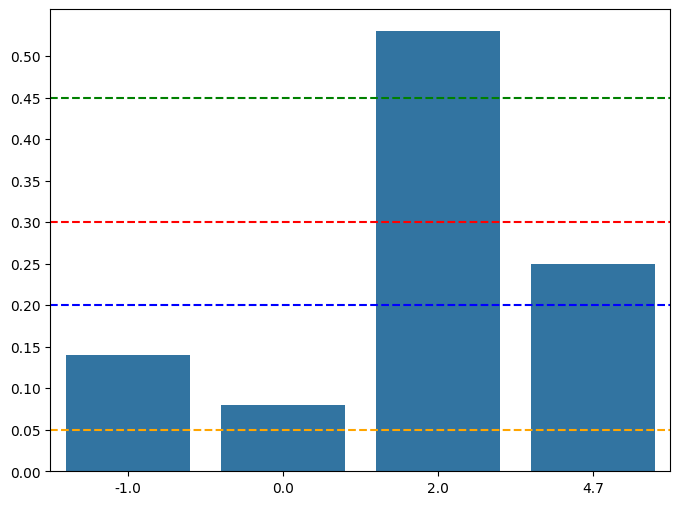

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/100)
ax.axhline(.2, c='b', linestyle='--')
ax.axhline(.05, c='orange', linestyle='--')
ax.axhline(.45, c='green', linestyle='--')
ax.axhline(.3, c='red', linestyle='--')
ax.set_yticks(np.arange(0, .55, .05));

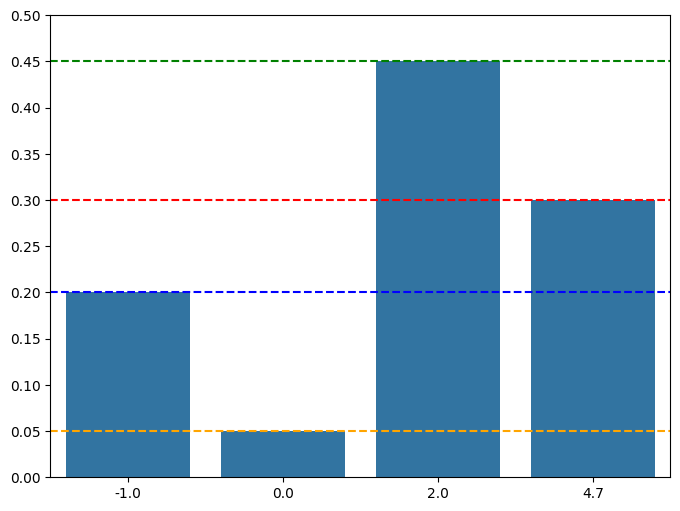

In [17]:
no_tries = 10**6
outcomes = rng.choice(X, p=[.2, .05, .45, .3], size=no_tries)
no_outcomes = np.unique(outcomes, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 6))



sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/no_tries)
ax.axhline(.2, c='b', linestyle='--')
ax.axhline(.05, c='orange', linestyle='--')
ax.axhline(.45, c='green', linestyle='--')
ax.axhline(.3, c='red', linestyle='--')
ax.set_yticks(np.arange(0, .55, .05));

***

Let's assume we have a following discrete random variable which can take infinitely many values:


$$ X :
\begin{pmatrix}
1 & 2 & \cdots & k & \cdots \\
p_1 & p_2 & \cdots & p_k & \cdots & 
\end{pmatrix}.
$$

Using its distribution, we can calculate probabilities of some events in the following manner (which also applies for finite RVs):

$$ P(X = k) = p_k $$

$$ P(X \leqslant k) = p_1 + p_2 + \cdots + p_k $$

$$ P(X < k) = P(X \leqslant k - 1) = p_1 + p_2 + \cdots + p_{k-1} $$

$$ P(3 \leqslant X \leqslant k) = p_3 + p_4 + \cdots + p_k $$

$$ P(X > k) = 1 - P(X \leqslant k) = 1 - (p_1 + p_2 + \cdots + p_k) $$

---

Probability $P(X\leqslant k)$ is quite an important one - it even has it's name *cumulative distribution function* or *c.d.f.*. It's denoted by $F(k)$, and it simply sums all the probabilities for all values up to $k$:

$$ F :
\begin{pmatrix}
1 & 2 &  3 & \cdots & N\\
p_1 & p_1 + p_2  & p_1 + p_2 + p_3 & \cdots & 1 
\end{pmatrix}.
$$

## R2.4 Discrete Type Distributions

Random or *stochastic* processes are not just some mathematical intellectual plaything. They occur all around us and within us. Many stochastic natural and social phenomena behave according to some distribution, and can be modelled according to that distribution. Here we go through some of those important discrete-type distributions.

### Bernoulli Distribution

The simplest discrete distribution is Bernoulli Distribution - it's a distribution of a RV that has binary outcomes - yes/no, hit/miss or success/failure. The *parameter* of this distribution is $p$ - the probability of 'hit'. This distribution looks like:

$$ X :
\begin{pmatrix}
0 & 1\\
1 - p & p
\end{pmatrix}.
$$

To sample from Bernoulli Distribution we can use `rng.choice()` with two outcomes. Say, we have a population that gives a 'yes' answer to some question in 2/3 cases and 'no' in 1/3 cases, and we want to draw a sample of 100 from it. Here's a sample:

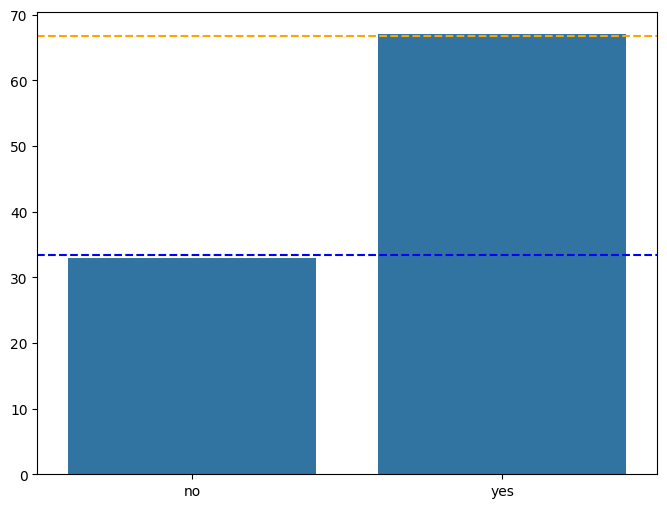

In [18]:
X = ['yes', 'no']

no_tries = 100
outcomes = rng.choice(X, p=[2/3, 1/3], size=no_tries)
no_outcomes = np.unique(outcomes, return_counts=True)


fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1])

ax.axhline(1/3*no_tries, c='b', linestyle='--')
ax.axhline(2/3*no_tries, c='orange', linestyle='--');

### Binomial Distribution

Binomial distribution gives an answer to the following question: *what's the probability of getting $k$ hits in $n$ trials of the same hit/miss experiment, having probability of hit equal to $p$?*

Binomial Distribution has two parameteres:

- $n$: number of repetitions of the same experiment
- $p$: probability of a hit (success)

If a random variable $X$ has a Binomial Distribution with parameters $n$ and $p$, we write that

$$ X \sim \mathcal{B}(n, p).$$

For example, we'd like to know what's the probability of landing 7 Tails in tossing a coin 10 times. We can approximate this probability by sampling from the Binomial Distribution with parameters $n=10$ and $p=0.5$ ($\mathcal{B}(100, 0.5)$), using `rng.binomial()`.

In [19]:
outcomes = rng.binomial(n=10, p=.5, size=100)
outcomes

array([6, 5, 5, 2, 5, 5, 6, 4, 6, 5, 4, 7, 3, 4, 4, 5, 4, 7, 4, 4, 3, 4,
       6, 7, 4, 4, 7, 4, 3, 6, 3, 5, 8, 5, 7, 5, 6, 2, 8, 6, 6, 4, 5, 6,
       3, 7, 5, 6, 5, 5, 3, 4, 7, 6, 3, 4, 5, 3, 7, 5, 7, 7, 3, 5, 5, 7,
       5, 4, 5, 6, 6, 3, 7, 4, 4, 5, 3, 4, 5, 5, 7, 5, 6, 6, 4, 6, 3, 6,
       8, 4, 6, 6, 7, 5, 7, 3, 8, 5, 5, 5])

In [20]:
no_outcomes = np.unique(outcomes, return_counts=True)
no_outcomes

(array([2, 3, 4, 5, 6, 7, 8]), array([ 2, 13, 20, 27, 19, 15,  4]))

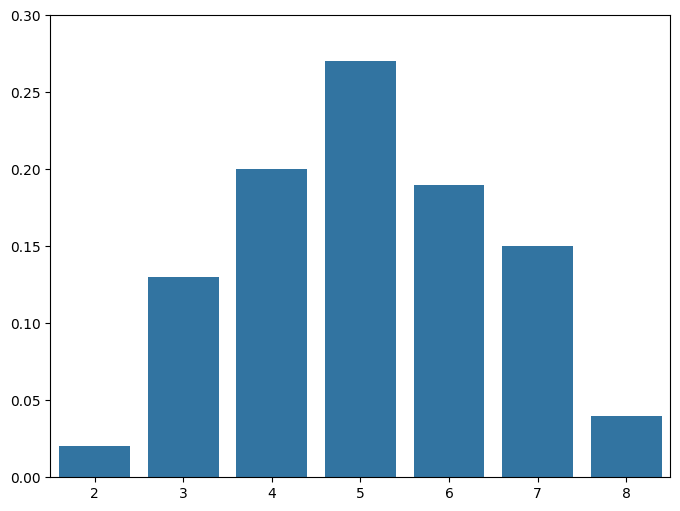

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/100)
ax.set_yticks(np.arange(0, np.max(no_outcomes[1]/no_tries) + .05, .05));

In [22]:
def sample_from_binomial(n, p, no_tries=10**6, k=None):
    
    outcomes = rng.binomial(n, p, size=no_tries)
    no_outcomes = np.unique(outcomes, return_counts=True)


    fig, ax = plt.subplots(figsize=(8, 6))

    sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/no_tries)
    
    if k:
        theor_p = math.comb(n, k)*p**k*(1-p)**(n-k)
        ax.axhline(theor_p, c='m', linestyle='--')

    ax.set_yticks(np.arange(0, np.max(no_outcomes[1]/no_tries) + .05, .05)); 

In [23]:
def cdf_binomial(n, p):
    outcomes = rng.binomial(n, p, size=10**6)
    no_outcomes = np.unique(outcomes, return_counts=True)


    fig, ax = plt.subplots(2, 1, figsize=(12, 6))

    sns.barplot(ax = ax[0], x = no_outcomes[0], y = no_outcomes[1]/10**6)
    sns.barplot(ax = ax[1], x = no_outcomes[0], y = np.cumsum(no_outcomes[1]/10**6))

    ax[0].set_yticks(np.arange(0, 1.2, .2));     
    ax[1].set_yticks(np.arange(0, 1.2, .2)); 

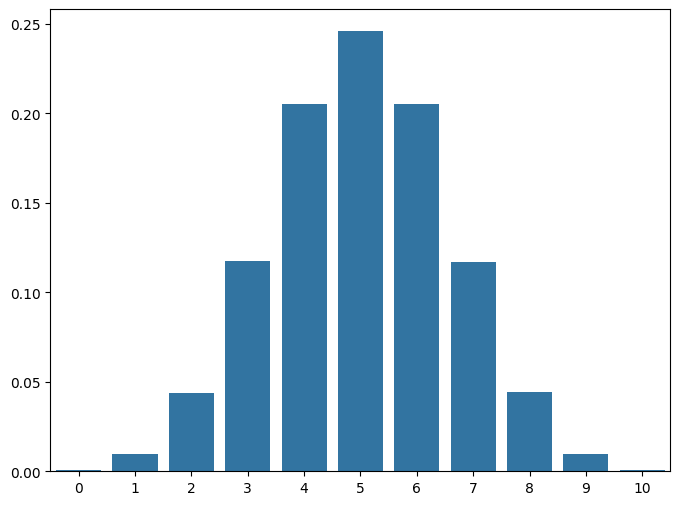

In [24]:
sample_from_binomial(n=10, p=.5, no_tries=10**6)

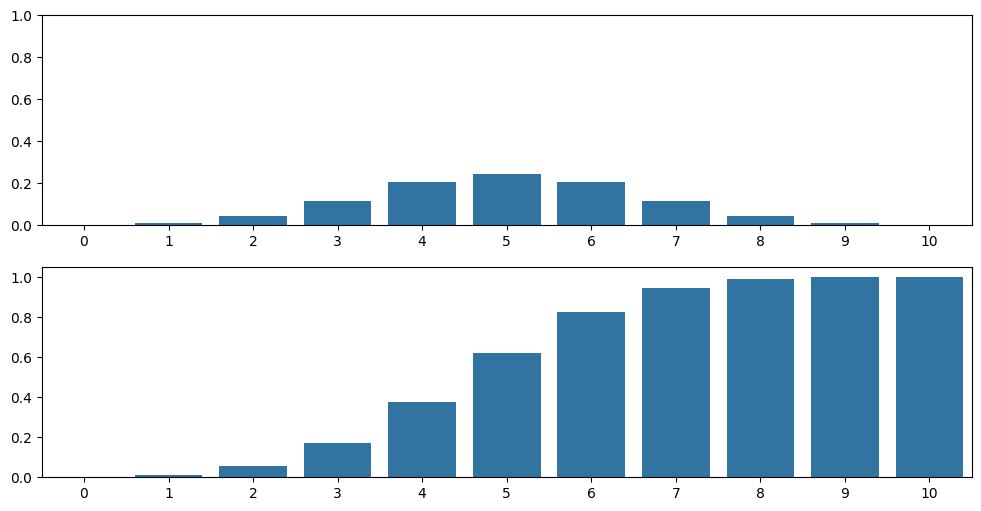

In [25]:
cdf_binomial(n=10, p=.5)

But we can actually calculate these probabilities theoretically, via

$$P(X = k) = \binom{n}{k}p^k(1-p)^{n-k},$$

where $\binom{n}{k}$, called *binomial coefficient*, is

$$\binom{n}{k} = \frac{n!}{k!(n-k)!}.$$

Say we have some unfair coin which lands Tails with probability 0.25, and we toss it three times. Using the formula above for $\mathcal{B}(3, 0.25)$ we obtain the probabilities for number of Tails in 3 tosses $X$:

$$ X :
\begin{pmatrix}
0 & 1 & 2 & 3\\
0.421875 & 0.421875 & 0.140625 & 0.015625
\end{pmatrix}.
$$

And to confirm the results experimentally:

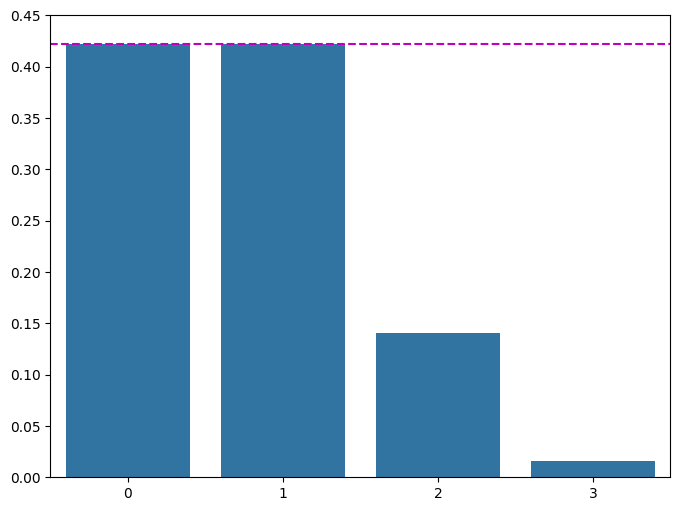

In [26]:
sample_from_binomial(n=3, p=.25, no_tries=10**6, k=1)

### Geometric Distribution

Geometric Distribution gives an answer to the following question: *what's the probability of getting the first hit in $k$th repetition of a hit/miss experiment, if the probability of a hit is $p$?* 

Geometric Distribution has only one parameter: probability of a hit $p$.

Random variable $X$ having Geometric Distribution has (countably) infinite values.

For example, we'd like to know what's the probability of getting a first 6 in 3rd roll of a six-sided die . We can approximate this probability by sampling from the Geometric Distribution with parameter $p=1/6$, using `rng.geometric()`.

In [27]:
outcomes = rng.geometric(p=1/6, size=100)
outcomes

array([ 5,  3,  6,  4,  3,  5,  6,  4,  3, 11,  5,  6,  2,  2,  1,  5,  9,
        2,  3,  2,  3, 10, 13, 13,  2,  7, 11,  5,  2,  1,  3,  3,  2,  8,
       10, 10, 11,  1,  2,  2,  5, 12,  8,  6,  5,  1,  7,  1,  9, 12,  1,
        1,  2,  5, 11,  4,  8,  2,  3,  4,  8,  1,  3,  2,  4,  1,  4, 11,
        9,  5,  1,  4,  1, 10,  4,  4, 12, 13, 15,  4, 19, 17,  5,  2,  6,
        4, 13,  3, 18,  1, 12,  2,  4,  2,  1,  9, 23,  4,  8, 13])

In [28]:
no_outcomes = np.unique(outcomes, return_counts=True)
no_outcomes

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 15, 17, 18, 19,
        23]),
 array([13, 15, 10, 13, 10,  5,  2,  5,  4,  4,  5,  4,  5,  1,  1,  1,  1,
         1]))

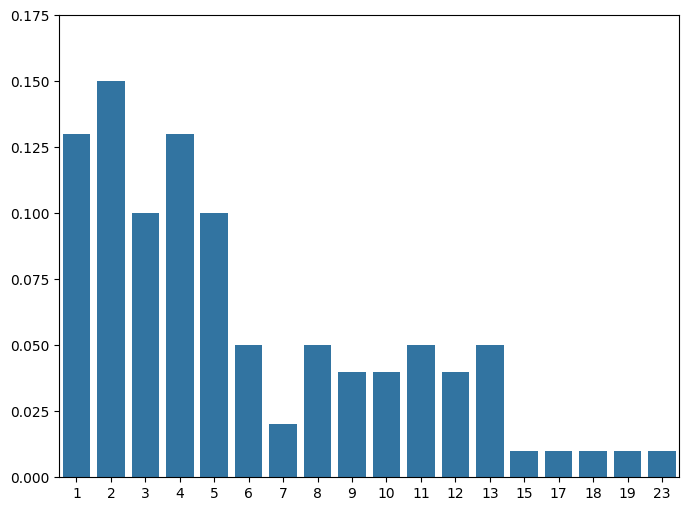

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/100)
ax.set_yticks(np.arange(0, .2, .025));

In [30]:
def sample_from_geometric(p, no_tries=10**6, k=None):
    
    outcomes = rng.geometric(p, size=no_tries)
    no_outcomes = np.unique(outcomes, return_counts=True)


    fig, ax = plt.subplots(figsize=(20, 6))

    sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/no_tries)
    
    if k:
        theor_p = (1-p)**(k-1)*p
        ax.axhline(theor_p, c='m', linestyle='--')



    ax.set_yticks(np.arange(0, np.max(no_outcomes[1]/no_tries) + .025, .025)); 

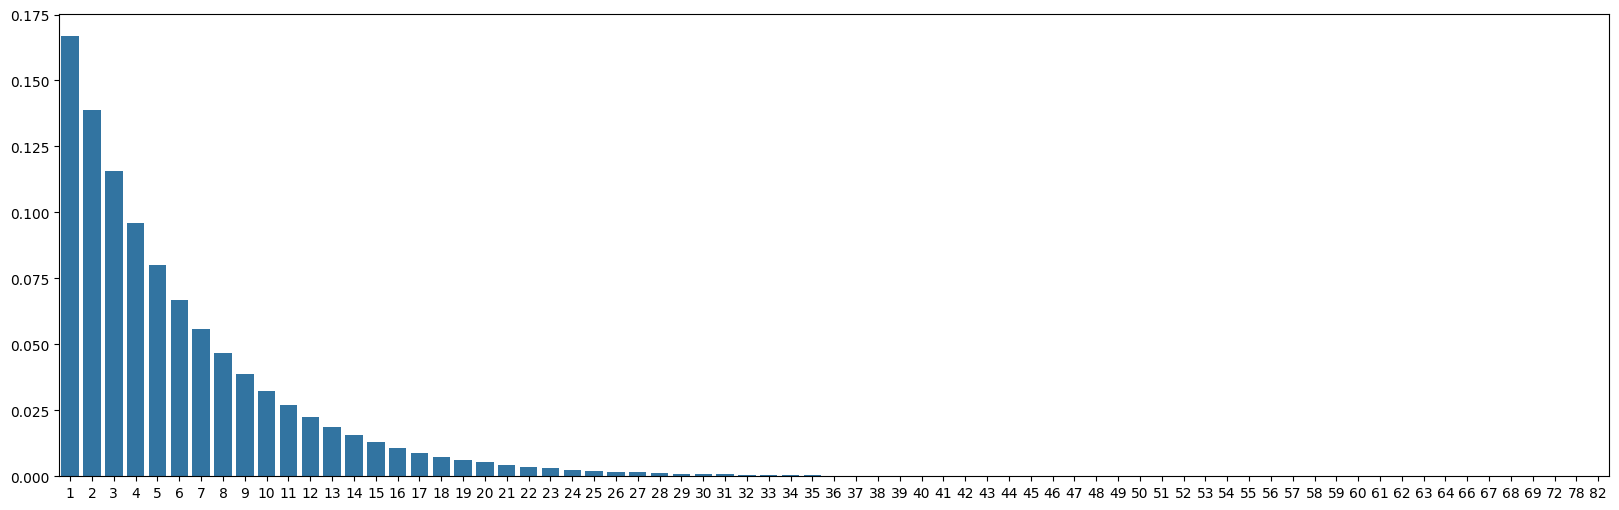

In [31]:
sample_from_geometric(p=1/6, no_tries=10**6)

We can calculate these probabilities theoretically using a formula for a RV having Geometric Distribution:

$$P(X=k) = (1-p)^{k-1}p.$$

So, for our example we have

$$P(X = 3) = \Big(\frac{5}{6}\Big)^2\cdot\frac{1}{6} = 0.1157407407... .$$

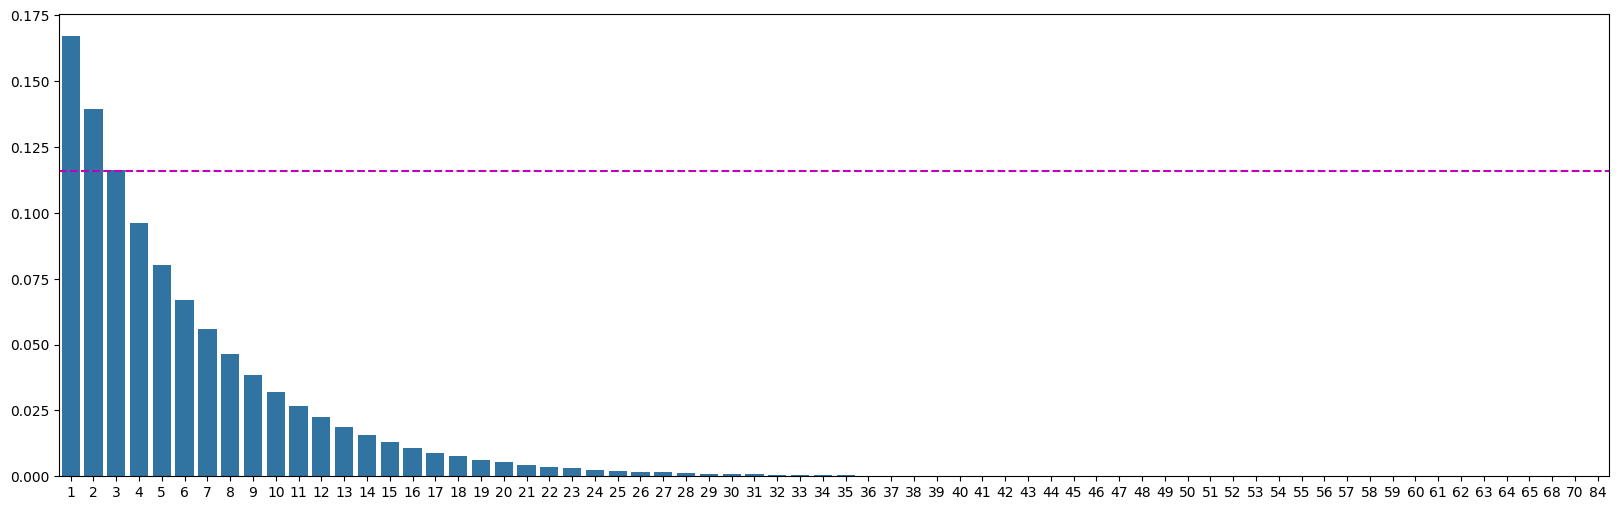

In [32]:
sample_from_geometric(p=1/6, no_tries=10**6, k=3)

In [33]:
def cdf_geometric(p):
    outcomes = rng.geometric(p, size=10**6)
    no_outcomes = np.unique(outcomes, return_counts=True)


    fig, ax = plt.subplots(2, 1, figsize=(22, 6))

    sns.barplot(ax = ax[0], x = no_outcomes[0], y = no_outcomes[1]/10**6)
    sns.barplot(ax = ax[1], x = no_outcomes[0], y = np.cumsum(no_outcomes[1]/10**6))

    ax[0].set_yticks(np.arange(0, 1.2, .2));     
    ax[1].set_yticks(np.arange(0, 1.2, .2)); 

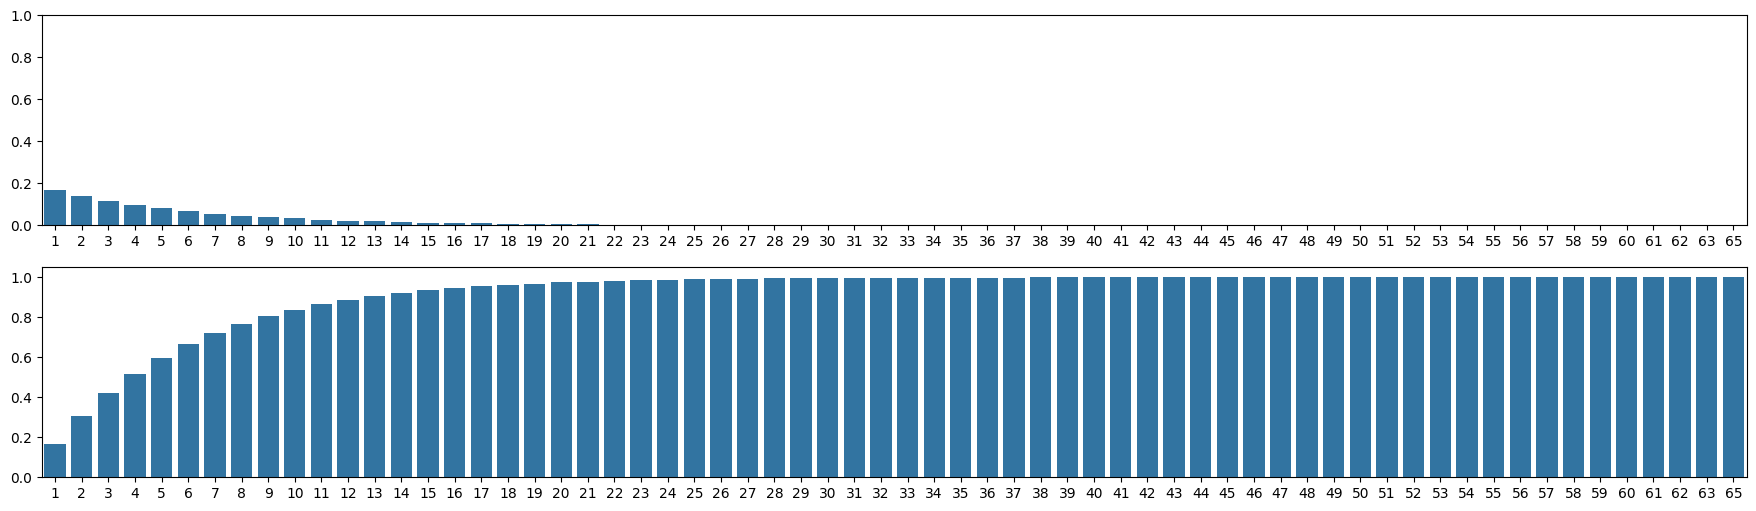

In [34]:
cdf_geometric(p=1/6)

### Discrete Uniform Distribution

This is actually a known one - it's a distribution of a RV where every outcome has the same probability: rolling a six-sided die, for example. The only parameter of this random variable is $N$ - number of values this RV can take. And the probability of each outcome is $\frac{1}{N}$.

We can sample from Discrete Uniform Distribution using `rng.choice()` without the `p` argument. 

Let's sample frequencies of each number when rolling a six-sided die. 

In [35]:
def sample_from_uniform(N, no_tries=10**6):
    
    outcomes = rng.choice(np.arange(1, N+1), size=no_tries)
    no_outcomes = np.unique(outcomes, return_counts=True)


    fig, ax = plt.subplots(figsize=(8, 6))

    sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/no_tries)
    ax.axhline(1/N, c='m', linestyle='--')

    ax.set_yticks(np.arange(0, np.max(no_outcomes[1]/no_tries) + .025, .025)); 

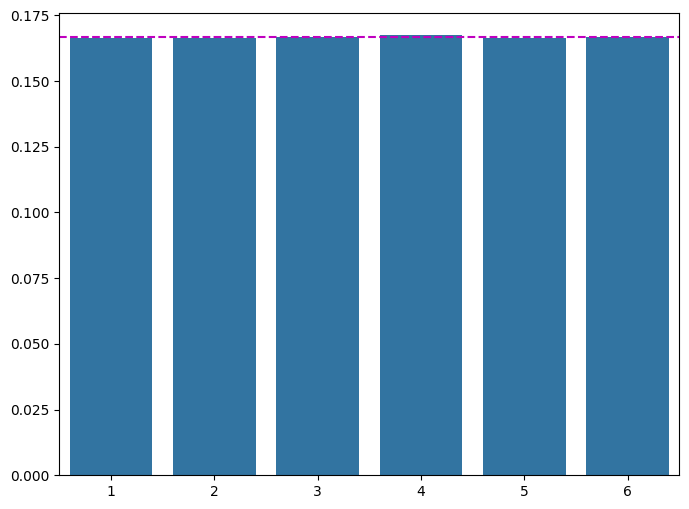

In [36]:
sample_from_uniform(N=6, no_tries=10**6)

### Poisson Distribution

Poisson Distribution gives an answer to the following question: *if the average number of occurences of an event during some time interval is $\lambda$ - what is the probability of that event occuring $k$ times during the that interval?* 

Poisson Distribution has only one parameter: average number of occurences $\lambda$.

Random variable $X$ having Poisson Distribution has (countably) infinite values.

We can sample from Poisson Distribution using `rng.poisson()`.

*Example* (Following and adapting from Ladislaus Bortkiewicz, 1898). Assumption: on the average, 10 soldiers in the Prussian army were killed accidentally by horse kick monthly. What is the probability that 17 soldies in the Prussian army will be accidently killed by horse kicks during the month?

In [37]:
outcomes = rng.poisson(lam=10, size=100)
outcomes

array([ 8,  8, 13, 11,  6, 10, 15, 15,  9,  8, 10,  6,  5,  9,  9,  9, 15,
       14,  7, 14,  8, 16, 12, 12, 10, 12,  9, 18, 13, 17, 12, 10, 10,  8,
       13,  6, 11,  8,  7, 11,  9,  9, 10,  9, 17, 10,  5, 11,  6, 16, 10,
        5,  9, 11, 11,  9, 14,  9, 11,  9,  7, 12,  7,  8, 11, 11, 10, 11,
        3,  7,  7,  5, 11,  9,  3,  5,  9,  9,  6,  7, 12, 13, 10,  4, 12,
        7, 10,  9,  8, 15,  9,  7,  8,  8, 11,  5,  9,  7,  8,  7])

In [38]:
no_outcomes = np.unique(outcomes, return_counts=True)
no_outcomes

(array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18]),
 array([ 2,  1,  6,  5, 11, 11, 18, 11, 12,  7,  4,  3,  4,  2,  2,  1]))

In [39]:
def sample_from_poisson(lam, no_tries=10**6, k=None):
    
    outcomes = rng.poisson(lam, size=no_tries)
    no_outcomes = np.unique(outcomes, return_counts=True)


    fig, ax = plt.subplots(figsize=(20, 6))

    sns.barplot(ax = ax, x = no_outcomes[0], y = no_outcomes[1]/no_tries)
    
    
    if k:
        p_theor = lam**k*np.exp(-lam)/math.factorial(k)
        ax.axhline(p_theor, c='m', linestyle='--')


    ax.set_yticks(np.arange(0, np.max(no_outcomes[1]/no_tries) + .025, .025)); 

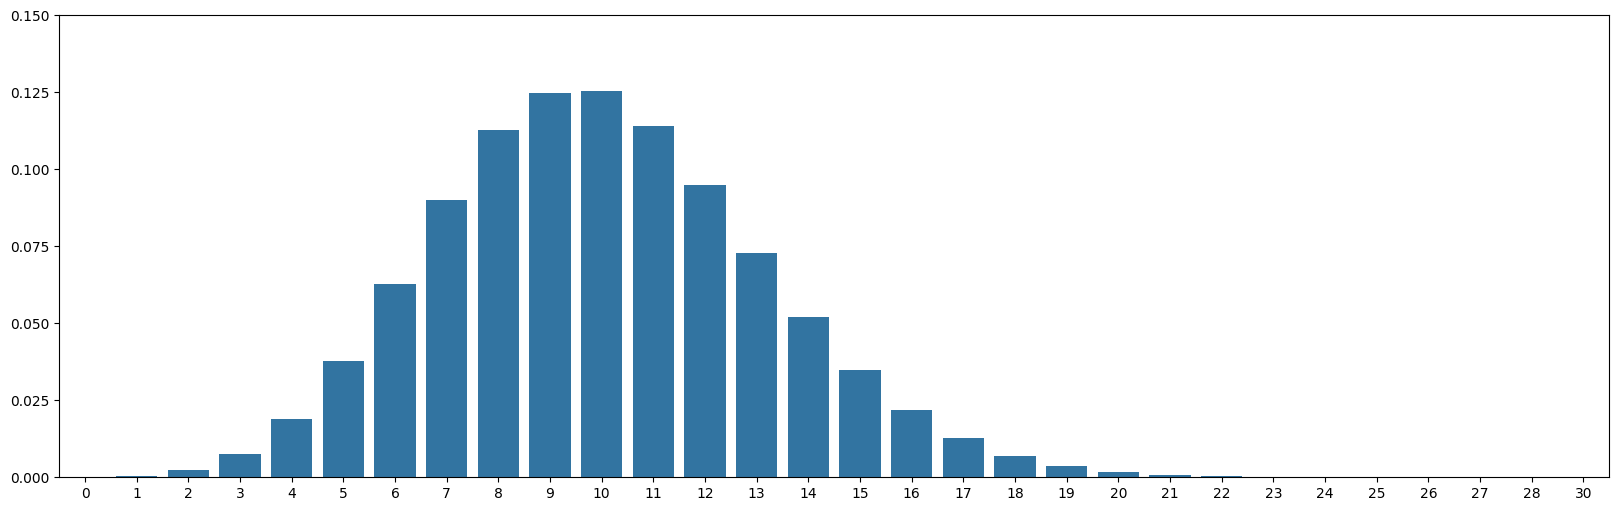

In [40]:
sample_from_poisson(lam=10, no_tries=10**6)

We can calculate these probabilities theoretically using a formula for a RV having Geometric Distribution:

$$P(X=k) = \frac{\lambda^ke^{-\lambda}}{k!}.$$

So, for our example, we have:

$$P(X = 17) = \frac{10^{17}\cdot e^{-10}}{17!} \approx 0.012764 $$

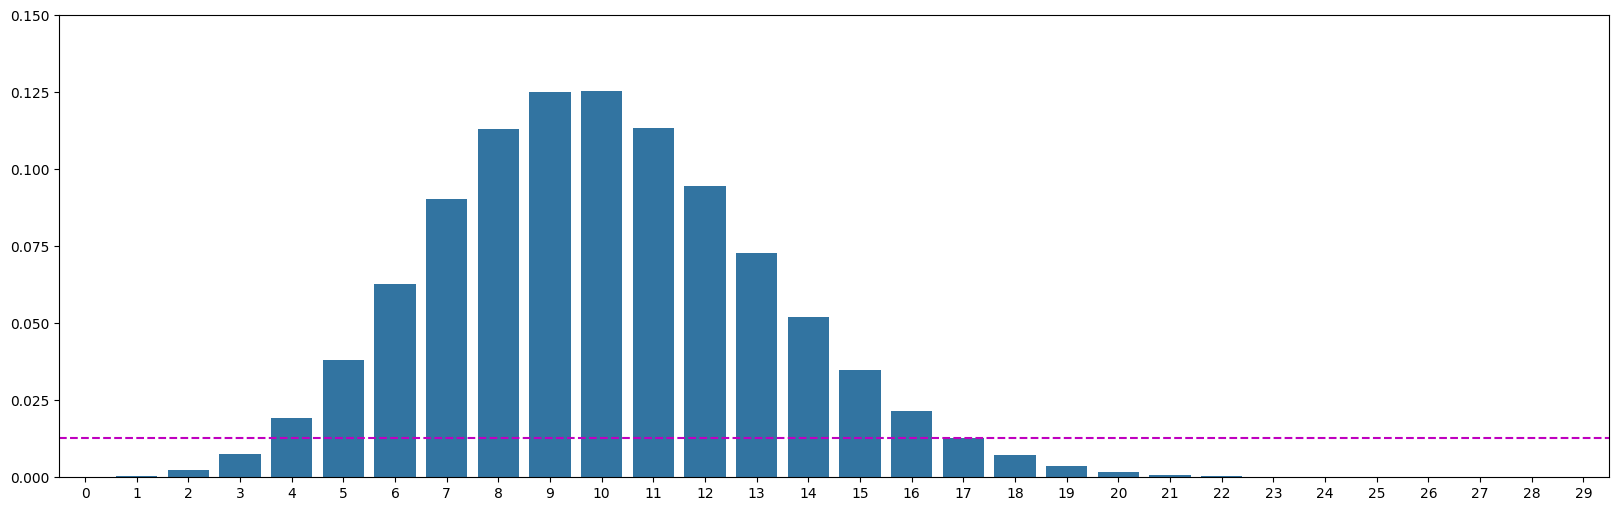

In [41]:
sample_from_poisson(lam=10, no_tries=10**6, k=17)

In [42]:
def cdf_poisson(lam):
    outcomes = rng.poisson(lam, size=10**6)
    no_outcomes = np.unique(outcomes, return_counts=True)


    fig, ax = plt.subplots(2, 1, figsize=(22, 6))

    sns.barplot(ax = ax[0], x = no_outcomes[0], y = no_outcomes[1]/10**6)
    sns.barplot(ax = ax[1], x = no_outcomes[0], y = np.cumsum(no_outcomes[1]/10**6))

    ax[0].set_yticks(np.arange(0, 1.2, .2));     
    ax[1].set_yticks(np.arange(0, 1.2, .2)); 

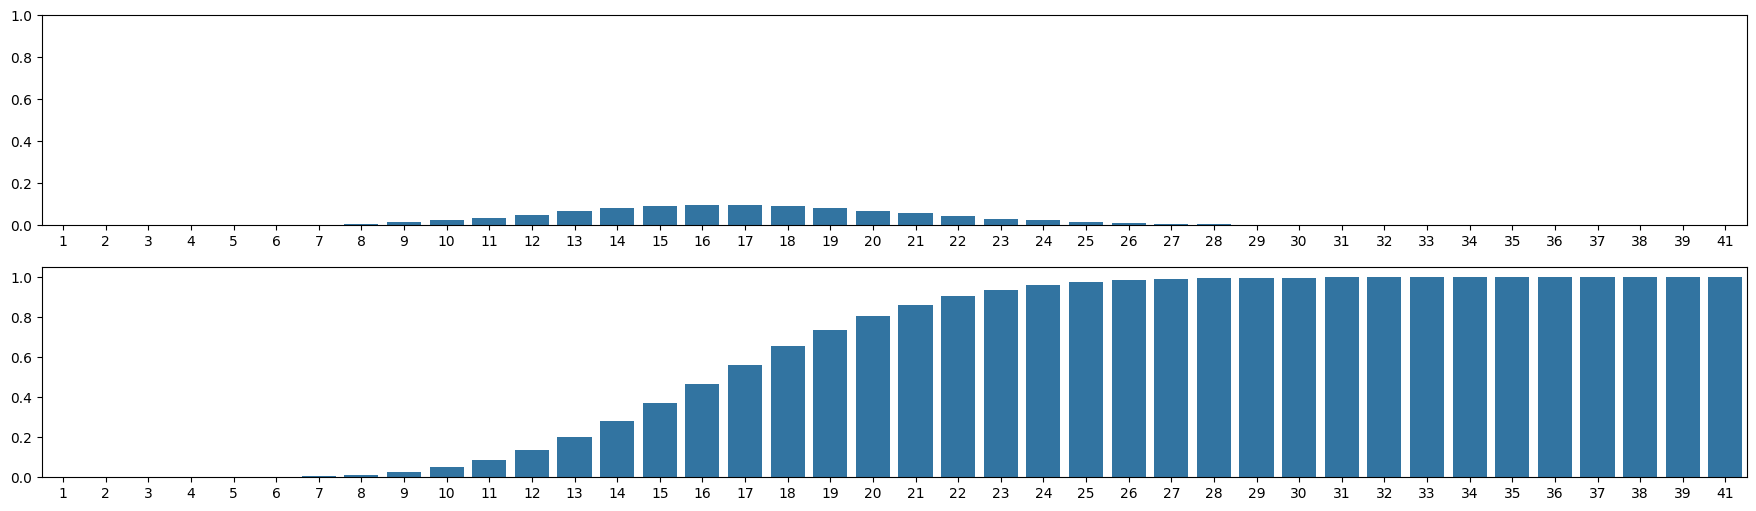

In [43]:
cdf_poisson(lam=17)

## R2.5 Distributions - Once More, with Feelings. With SciPy

SciPy is a Python module much used by statisticians, which we are also going to be using a bit during our course. SciPy comes quite handy if we need to work with random variables having some known distribution - not only we can use SciPy's methods for sampling from a given distribution, we can use them to calculate theoretical probabilities and c.d.f values. 

Let's first import it.

In [44]:
import scipy

### Binomial Distribution 

For Binomial Distribution we use `binom` object from `scipy.stats` module

In [45]:
from scipy.stats import binom

We can sample from $\mathcal{B}(10, 0.5)$ using `binom.rvs()` method:

In [46]:
binom.rvs(n=10, p=.5, size=100)

array([6, 7, 4, 5, 6, 6, 5, 5, 8, 5, 6, 3, 5, 5, 4, 5, 5, 9, 6, 3, 3, 4,
       5, 4, 4, 4, 4, 7, 4, 5, 7, 6, 5, 6, 4, 3, 5, 3, 5, 6, 2, 4, 4, 7,
       7, 7, 4, 6, 5, 3, 4, 3, 8, 3, 5, 7, 4, 6, 3, 5, 4, 5, 7, 6, 8, 6,
       4, 7, 5, 5, 6, 4, 3, 6, 5, 4, 7, 4, 6, 4, 4, 5, 4, 4, 3, 4, 7, 4,
       5, 4, 5, 6, 4, 4, 3, 6, 4, 6, 7, 7])

*If we roll a 20-sided die 100 times, what's the probability of getting 20 ten times?*

Here we have $\mathcal{B}(1000, 1/20)$, and $k=10$. We can calculate this probability using `binom.pmf()` method:

In [47]:
binom.pmf(k=10, n=100, p=1/20)

np.float64(0.016715884095931433)

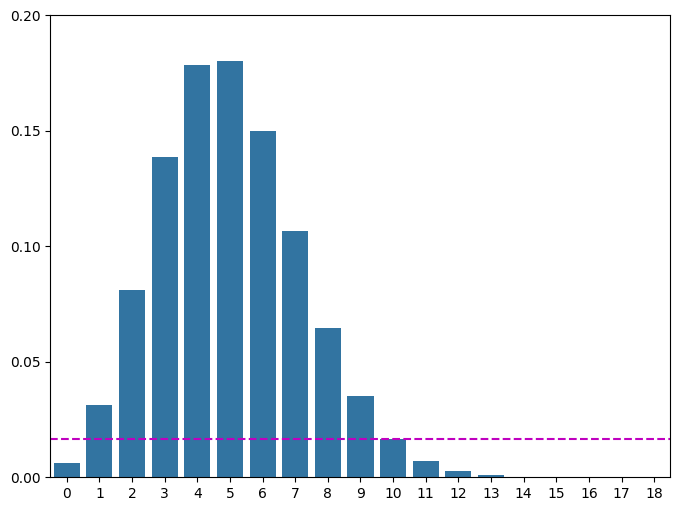

In [48]:
sample_from_binomial(n=100, p=1/20, k=10)

*What's the probability of getting 20 ten or less times?* We can calculate that using `binom.cdf()` method:


In [49]:
binom.cdf(k=10, n=100, p=1/20)

np.float64(0.9885275899325153)

*What's the probability of getting 20 more than ten times?*


In [50]:
1 - binom.cdf(k=10, n=100, p=1/20)

np.float64(0.011472410067484673)

### Poisson Distribution 

For Poisson Distribution we use `poisson` object from `scipy.stats` module

In [51]:
from scipy.stats import poisson

We can sample from Poisson Distribution with $\lambda = 5$ using `poisson.rvs()` method (which is given as $\mu$ for scipy):

In [52]:
poisson.rvs(mu=5, size=100)

array([ 9,  8,  6,  4,  4,  9,  5,  4,  9,  5,  6,  4,  4,  9,  4,  7,  4,
        5,  3,  6,  4,  6,  5,  5,  6,  8,  3, 10,  3,  9,  3,  4,  7,  5,
        4,  5,  4,  2,  3,  4,  3,  6,  8,  0,  4,  6,  6,  6,  6,  4,  8,
        6,  2,  8,  3,  8, 11,  3,  5,  4, 11,  5,  5,  4,  4,  6,  5,  2,
        7,  2,  3,  7,  5, 11,  4,  4,  6,  4,  4,  8,  4,  2,  8,  5,  8,
       10,  2,  2,  6,  3,  7,  6,  2,  8,  5,  2,  6,  8,  5,  4])

*What's the probability of 7 people entering a store in an one-hour period, if we know that 5 people enter the store, in average, in one-hour period?*

In [53]:
poisson.pmf(k=7, mu=5)

np.float64(0.10444486295705395)

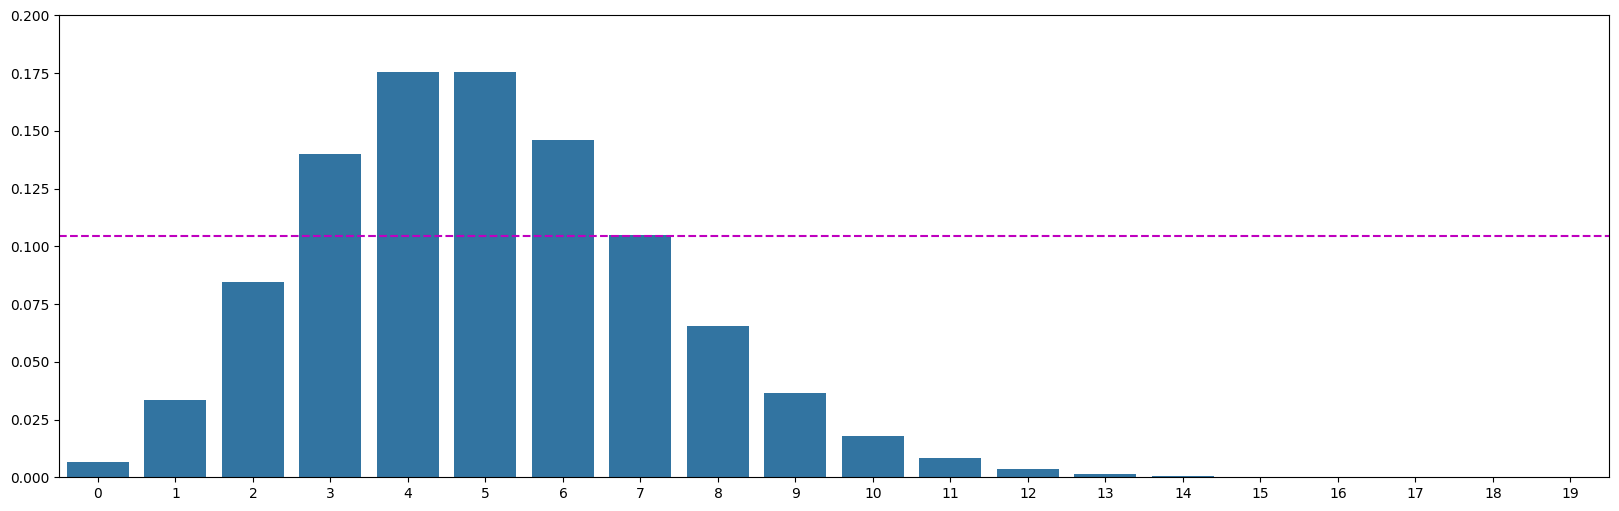

In [54]:
sample_from_poisson(lam=5, k=7)

*On the average, 10 soldiers in the Prussian army were killed accidentally by horse kick monthly. What is the probability that **17 or more** soldies in the Prussian army will be accidently killed by horse kicks during the month?*

In [55]:
1 - poisson.cdf(mu=10, k=17)

np.float64(0.01427761359704971)

***
> **Bridge — from counting to measuring.** Sections R2.1–R2.5 built the world of **discrete** random variables: outcomes you can count, one by one — heads, sixes, arrivals per hour. But much of what an analyst actually measures is **continuous**: time on page, revenue, delivery minutes, a customer's height. The next three sections rebuild the same machinery — distribution, expectation, variance — for continuous quantities, where the probability of any single exact value is zero and probability instead becomes *area under a curve*.

## R2.6 Continuous-type Random Variable

We spoke about RVs that can take values from universal set $\Omega$ which is either finit or countably infinite; these were discrete-type random variables. But what if $\Omega$ is uncountably infinite,i.e. what if random variable $X$ can take any real number as a value? Then we have *(absolutely) continuous* random variable.

As with discrete-type RVs, continuous-type RVs have their distribution. With discrete RVs we use probability mass function (p.m.f) to describe their distribution. With continuous RVs, we have *probability density function (p.d.f)* which 'describes' them. One p.d.f. $\varphi(x)$ of a continuous random variable may look like this:




![](../_img/cdf.jpeg)

Each p.d.f of a continuous RV should be defined, continuous and non-negative almost everywhere on the whole real-number line, and:

$$\int_{-\infty}^{+\infty}\varphi(x)dx = 1.$$

Don't worry about the integral - we are not going to compute integrals in this course. But we do need them to calculate probabilities for continuous RVs. The integral above tells us that the area under the curve of p.d.f. is always equal to 1. This seems familiar? This is actually completely analogous to the fact that, for discrete RV, all probabilities in its p.m.f. need always to sum to 1. 


So, what's the probability of RV, having p.d.f as in the figure above, to take value -5.5? It's

$$P(X = -0.5) = 0.$$

OK, that kinda makes sense. But, what about the probability of taking value 0?

$$P(X = 0) = 0.$$

Wait, what? And taking value $\sqrt{2}$?

$$P(X = \sqrt{2}) = 0.$$

Is it always going to be zero? Yes. Because the probability of hitting a point exactly you want, out of uncountably infinitely many others is - of course, zero. But how we can calculate probabilities at all, if the probability of every point is zero? We just need to broaden our views - not to ask about the probability of hitting a single point $x$ among ridiculously infinitely many, but to ask about the probability of hitting any point in the small interval $\Delta x$ which contains $x$... and uncountably infinite many other points. When working with continuous RVs we can hope to get positive probability only if we work with intervals, no matter how big or small. 

However, to get positive probabilities, those intervals need to be either fully or partially on the *support* of p.d.f. Support is the part of p.d.f. curve where this function is positive, i.e. $\varphi(x) > 0$. For really small intervals $\Delta x$ that are outside of the support, i.e. for which $\varphi(x) = 0$, there is 0 probability for RV $X$ to take any value from that interval. On the other hand, if we observe a really small interval $\Delta x$ around the point where p.d.f. takes its maximal value - there is the highest probability of RV $X$ taking values from this interval. 

In other words: higher the value of $\varphi(x)$ for some $x$ - higher the probability of RV $X$ getting some value from a very small interval $\Delta x$ around $x$. (but not in $x$ itself; there, the probability is zero)

***

So, we can calculate probability of continuous RV in any interval. How do we calculate probability of RV $X$ taking values in some interval $[a, b]$ where $a$ and $b$ are two numbers? Simply, using the formula:

$$P(a \leqslant X \leqslant b) = \int_a^b\varphi(x)dx.$$

It's that integral again... And again it makes sense again. Remember that, using Kolmogorov Axioms, we defined probability as a measure? We also mentioned that integral is the measure of the area under the curve. So, using an integral to measure area under the curve of p.d.f on some interval $[a,b]$, we are actually measuring the probability of RV $X$ to take any value from that interval.

Observing probabilites as integrals, i.e. areas of surfaces under the p.d.f curve is completely in-sync with Kolmogorov Axioms for probability-as-a-measure:

- Both probability and area are measures, and cannot be negative;
- Area of an empty set, or a point/line is zero. So is the probability;
- Bigger the area, bigger the probability; and we may encompass big areas by taking long intervals or intervals around high values of p.d.f;
- We can just sum areas of disjoint figures to get the total area; the same is for probabilities of disjoint events.

One more important point. We saw that for discrete RVs every point matters (even if it's infinite). For some discrete RV $X$ we have

$$P(X \leqslant k) \neq P(X < k).$$

However, this is not the case with continuous RVs; there one point doesn't make a difference (why?). So, for some continuous RV $X$ we have

$$P(a \leqslant X \leqslant b) = P(a \leqslant X < b) = P(a < X < b).$$

***

As discrete RVs have c.d.f, so continuous RVs have one as well. Cumulative distribution function for a continuous random variable is given with 

$$F(a) = P(X\leqslant a) = \int_{-\infty}^a\varphi(x)dx.$$

C.d.f of a continuous RV $X$ gives the probability of $X$ taking any value from the interval $(-\infty, a]$. Or, area under the p.d.f curve on that interval. Here's how one c.d.f. of a continuous RV looks like:

![](../_img/cdf.png)

C.d.f. is a prety handy tool for computing probabilities of continuous RVs, even more useful than p.d.f! In fact, by knowing the c.d.f we can compute probabilites while avoiding integrals, using this formula:

$$P(a \leqslant X \leqslant b) = F(b) - F(a).$$

And we can also calculate 

$$P(X \geqslant a) = 1 - P(X < a) = 1 - F(a).$$

***

For continuous RVs very useful is *quantile function*, which is the inverse of a c.d.f:

$$Q(p) = F^{-1}(p),\qquad p\in(0, 1).$$

Simply put, for $p = 0.1$ we can get a value $x$ for which we can expect to find 10% of points in the interval $(-\infty, x]$ when sampling from a RV $X$ having c.d.f $F$. 

The most important values for $p$ for the quantile functions are 0.25, 0.5 and 0.75, which give values for quartiles Q1, Q2 (median) and Q3. 

## R2.7 Continuous-type Random Variable Distributions

Enough of theoretical talk, and let's do some coding now. 

In [56]:
import numpy as np
import pandas as pd
import scipy
import math
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(seed=1023)

### Continuous Uniform Distribution

Continuous Uniform Distribution $\mathcal{U}[a, b]$ describes an experiment where there is an arbitrary outcome that lies in the interval $[a, b]$. In other words, we can equally expect any number in the interval $[a, b]$; no part of this interval is favoured than the other. 

We can sample from from Uniform Distribution on [0, 1] interval using `rng.random()`:

In [57]:
rng.random()

0.3388690800085262

In [58]:
rng.random(size=10)

array([0.90589874, 0.90960195, 0.74722338, 0.82310232, 0.26763656,
       0.08770086, 0.26731961, 0.70165033, 0.77665833, 0.37364504])

In [59]:
def sample_from_uniform_scatter(sample_size=10**2, perc=None):
    
    sample = rng.random(size=sample_size)

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.scatterplot(x=sample, y=0, color='c')

    ax.axhline(0, c='k', linestyle='--', alpha=.2)
    
    if perc:
        ax.axvline(perc, c='m', linestyle='--')

    ax.set_xticks(np.arange(-.1, 1.2, .1));
    
    return sample

array([0.16165231, 0.30668439, 0.29964548, ..., 0.52466025, 0.00373206,
       0.29818011], shape=(10000,))

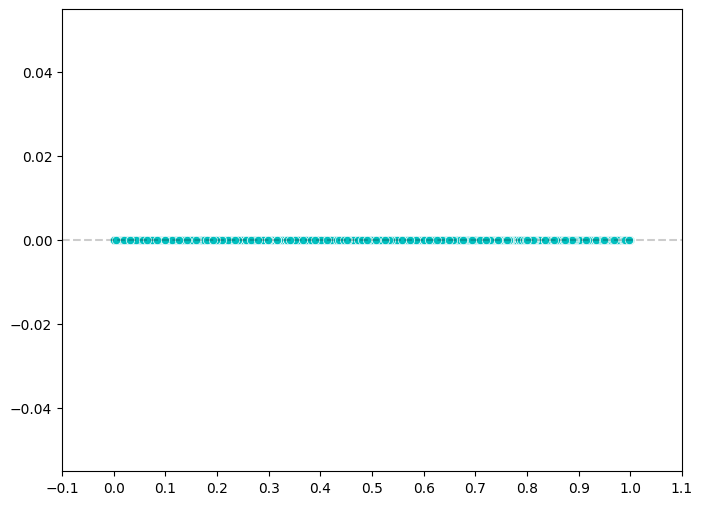

In [60]:
sample_from_uniform_scatter(sample_size=10**4)

By sampling big enough sample from $\mathcal{U}[0, 1]$ we might get a sense of how its p.d.f looks like.

In [61]:
def sample_from_uniform_hist(sample_size=10**6):
    
    fig, ax = plt.subplots(3, 1, figsize=(24, 18))
    
    outcomes = rng.random(size=sample_size)
    
    sns.histplot(ax=ax[0], x=outcomes, bins=10, stat='density')
    sns.histplot(ax=ax[1], x=outcomes, bins=10, stat='probability')
    sns.histplot(ax=ax[2], x=outcomes, bins=10, stat='probability', cumulative=True)
    
    ax[0].set_xticks(np.arange(0, 1.1, .1))
    ax[1].set_xticks(np.arange(0, 1.1, .1))
    ax[2].set_xticks(np.arange(0, 1.1, .1))
    
    ax[1].set_yticks(np.arange(0, 1.2, .2))
    
    ax[2].set_ylabel('Cumulative Probability')

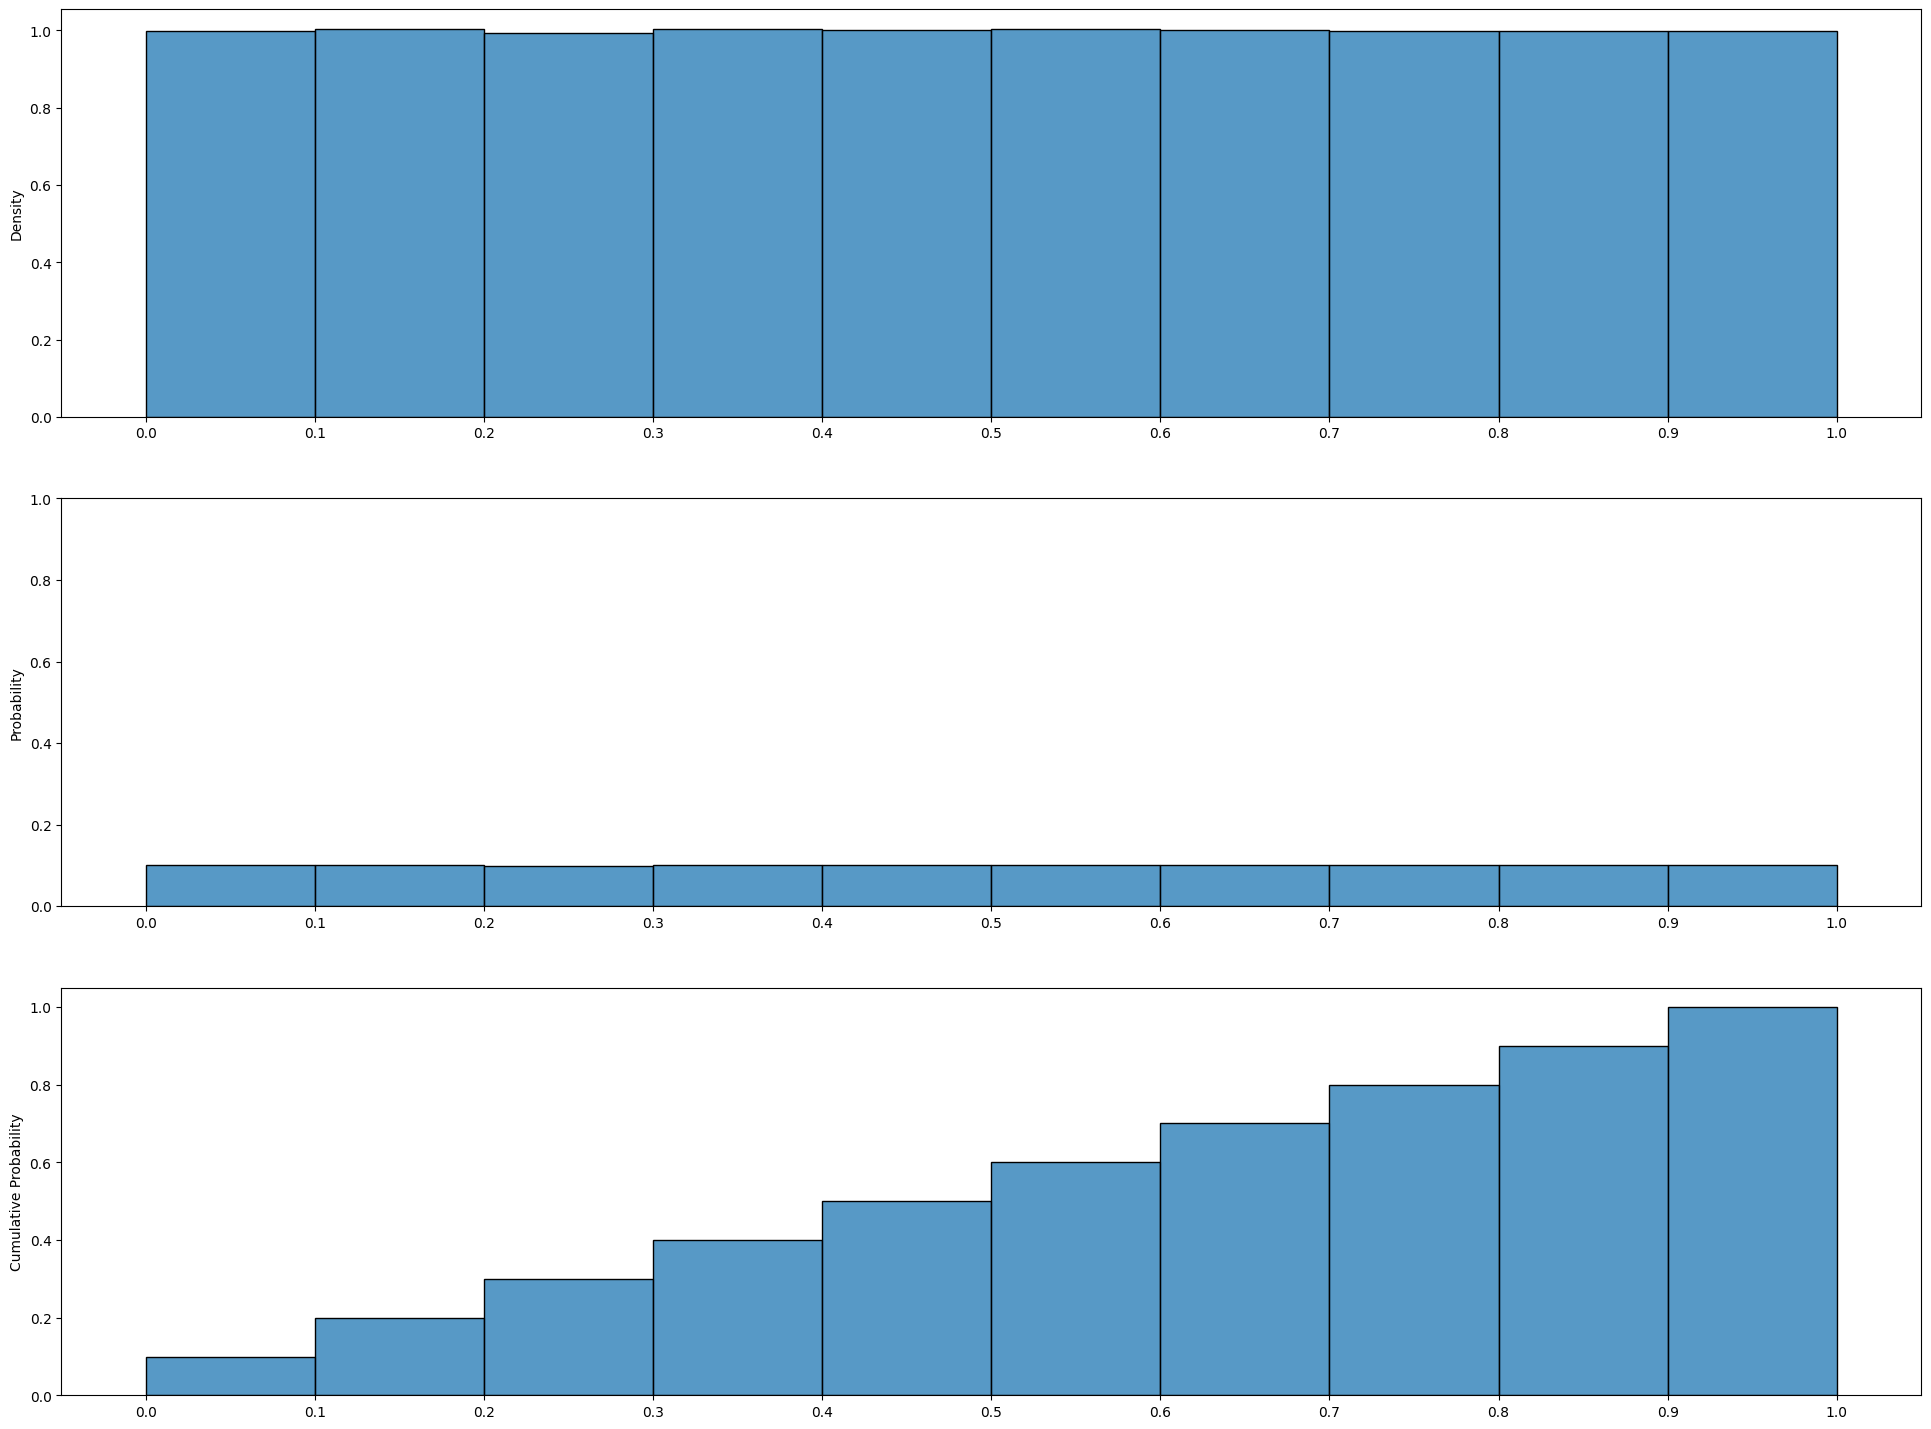

In [62]:
sample_from_uniform_hist(sample_size=10**6)

For RV $X\sim\mathcal{U}[a, b]$ we have its p.d.f, c.d.f and quantile function:

$$\varphi(x) = 
\begin{cases}
\frac{1}{b-a},\quad x\in[a, b],\\
0,\quad {\rm otherwise}.
\end{cases}
$$

$$\$$

$$F(x) = 
\begin{cases}
0,\quad x < a,\\
\frac{x-a}{b-a},\quad a\leqslant x\leqslant b,\\
1,\quad x > b.
\end{cases}
$$

$$\$$

$$Q(p) = a + p(b-a).$$

*We are sampling numbers from interval $[1, 4]$ uniformly at random. What is the probability of getting a number in the subinterval $[2, 3]$?*

So, we have $X\sim\mathcal{U}[1,4]$, and we calculate

$$P(2 < X < 3) = F(3) - F(2) = \frac{3-1}{4-1} - \frac{2-1}{4-1} = \frac{2}{3} - \frac{1}{3} = \frac{1}{3},$$

Which makes sense - subinterval [2, 3] is one third of the [1, 4] interval.

*What's the probability of getting a number greater than 3.99?*

$$P(X > 3.99) = 1 - F(3.99) = 1 - \frac{2.99}{3} \approx 1 - 0.9967 = 0.0033.$$

*If we sample numbers from interval $[0, 1]$ uniformly at random, find the point $x$ in that interval below which we expect to have 75% of our sample.*

Here we use quantile function

$$x = Q(0.75) = 0 + 0.75\cdot 1 = 0.75,$$

which is also an expected answer, given that we're sampling from the uniform distribution.

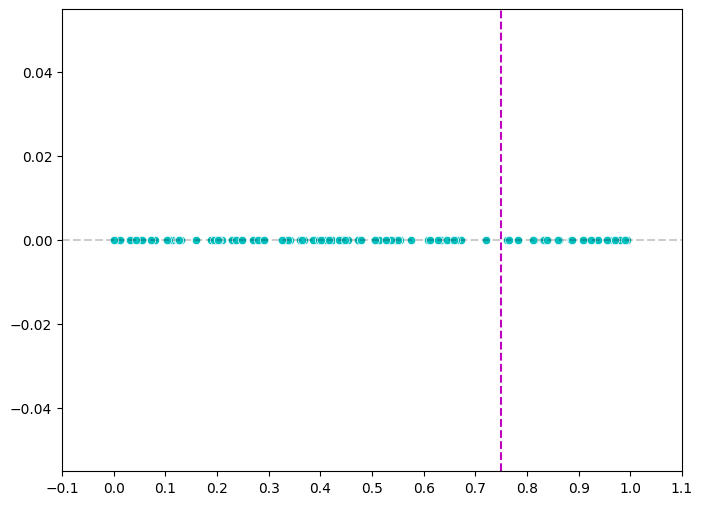

In [63]:
sample = sample_from_uniform_scatter(sample_size=10**2, perc=.75)

In [64]:
#ratio of points below 0.75

len(sample[sample < .75])/len(sample)

0.76

#### SciPy-stuff

For Continuous Uniform Distribution we use `uniform` object from `scipy.stats` module:

In [65]:
from scipy.stats import uniform

By default, `uniform` samples from $\mathcal{U}[0,1]$. If we want to sample from some other interval, we need to pass `loc` and `scale` in as arguments in its methods. Then we sample from $\mathcal{U}[{\rm loc,\ loc\ +\ scale}]$.

For example, if we want to sample from $\mathcal{U}[-1.1,\ \pi]$ we do:

In [66]:
uniform.rvs(loc=-1.1, scale=1.1 + math.pi, size=100)

array([ 0.91775672,  0.62910927,  2.53164817, -0.04236386,  0.28862012,
        0.94713489,  2.86036713,  2.79612114,  1.28100439, -0.94970253,
        2.84435787,  1.48528035,  1.07191823,  1.31367372,  0.41367224,
       -0.45022437,  0.14181885, -1.06230231, -0.33312805,  1.51748678,
       -0.31845969,  2.66569682,  2.86241634, -0.82747113, -0.24926958,
       -0.15441944,  0.71272347,  0.57440596,  1.62738177,  2.64047764,
        1.80444012,  0.35360763, -0.74092728,  0.70598249,  1.29372485,
       -0.54681425,  0.05887068, -0.49644653, -0.58935558,  2.9633077 ,
        2.39024587,  0.12063304,  1.73823817,  1.33648062, -0.18910367,
        2.09514266,  2.62239385,  3.12412742,  2.19355989, -1.09274446,
        1.84726406,  1.59106379,  1.94191966,  2.5023604 ,  1.5735564 ,
       -0.40484743, -0.79755419,  0.74194709, -0.39149245,  2.53771773,
        2.38786559,  2.40173151, -0.67154116,  1.51234697, -0.36731732,
       -0.16119272,  1.69725806,  1.87869297,  0.87200332,  3.03

If we want to compute a value of p.d.f for RV $X\sim\mathcal{U}[-1.1,\ \pi]$ at some point $x$, we use `.pdf()` method:

In [67]:
uniform.pdf(x=3, loc=-1.1, scale=1.1 + math.pi)

np.float64(0.2357604988667803)

In [68]:
uniform.pdf(x=math.sqrt(2), loc=-1.1, scale=1.1 + math.pi)

np.float64(0.2357604988667803)

In [69]:
uniform.pdf(x=3.2, loc=-1.1, scale=1.1 + math.pi)

np.float64(0.0)

We can answer questions posed above for RV $X\sim\mathcal{U}[1, 4]$, without needing to do any calculations using `.cdf()` method:

In [70]:
uniform.cdf(x=3, loc=1, scale=3) - uniform.cdf(x=2, loc=1, scale=3)

np.float64(0.3333333333333333)

In [71]:
1 - uniform.cdf(x=3.99, loc=1, scale=3)

np.float64(0.0033333333333332993)

We can also look for values of quantile function using `.ppf()` method (because quantile function is also called *percent point function*):

In [72]:
uniform.ppf(q=.75)

np.float64(0.75)

### Exponential Distribution

Exponential distribution is the distribution of time between events in a process in which same events occur continuously and independently at a constant average rate. It's denoted by $\mathcal{E}(\beta)$, where $\beta$ is its parameter, called *scale parameter*, and it denotes an average time by which event should occur.

We can sample from Exponential Distribution using `rng.exponential()`:

In [73]:
rng.exponential(scale=3)

5.665433724043872

Let's sample bigger sample from $\mathcal{E}(3)$, to see how the points are going to be distributed.

In [74]:
def sample_from_exponential_scatter(beta, sample_size=10**2, perc=None):
    
    sample = rng.exponential(scale=beta, size=sample_size)

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.scatterplot(x=sample, y=0, color='c')

    ax.axhline(0, c='k', linestyle='--', alpha=.2)
    
    if perc:
        
        med = -beta*np.log(1-perc)
        ax.axvline(med, c='m', linestyle='--')


    ax.set_xticks(np.arange(0, sample.max() + 1, 1));
    
    return sample

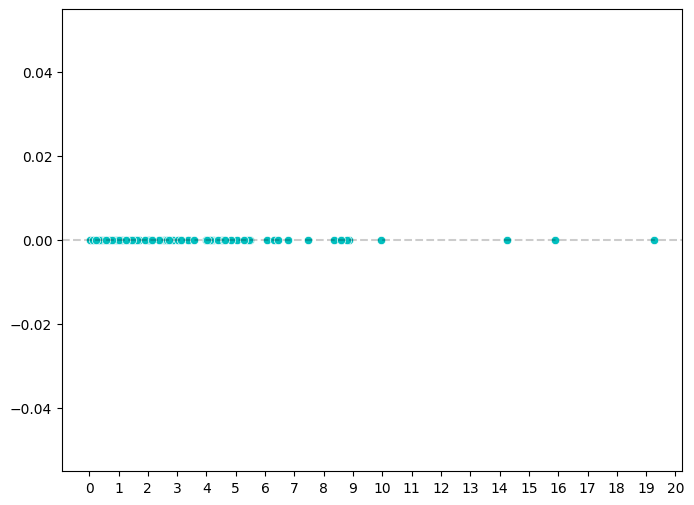

In [75]:
sample_from_exponential_scatter(3, sample_size=10**2);

But to get the true feel of how p.d.f. and c.d.f look like for Exponential Distribution, we'll use the following example:

Exponential Function can be used to model particle decay, which is a stochastic process. A particle decays at random time, which follows $\mathcal{E}(\beta)$ distribution, where $\beta$ is an average *lifetime of a particle*. Let's observe a particle that has an average lifetime of some unit inerval $\beta = 1$. We sample $N$ particles from a population of these particles and plot their lifetimes using histogram.

In [76]:
def sample_from_exponential_hist(beta, sample_size=10**3):
    
    fig, ax = plt.subplots(3, 1, figsize=(24, 18))
    
    sample = rng.exponential(scale=beta, size=sample_size)
    
    sns.histplot(ax=ax[0], x=sample, bins=100, stat='density')
    sns.histplot(ax=ax[1], x=sample, bins=100, stat='probability')
    sns.histplot(ax=ax[2], x=sample, bins=100, stat='probability', cumulative=True)
    
    ax[0].set_xticks(np.arange(0, sample.max() + 1, 1))
    ax[1].set_xticks(np.arange(0, sample.max() + 1, 1))
    ax[2].set_xticks(np.arange(0, sample.max() + 1, 1))
    
    ax[1].set_yticks(np.arange(0, 1.2, .2))
    
    ax[2].set_ylabel('Cumulative Probability')

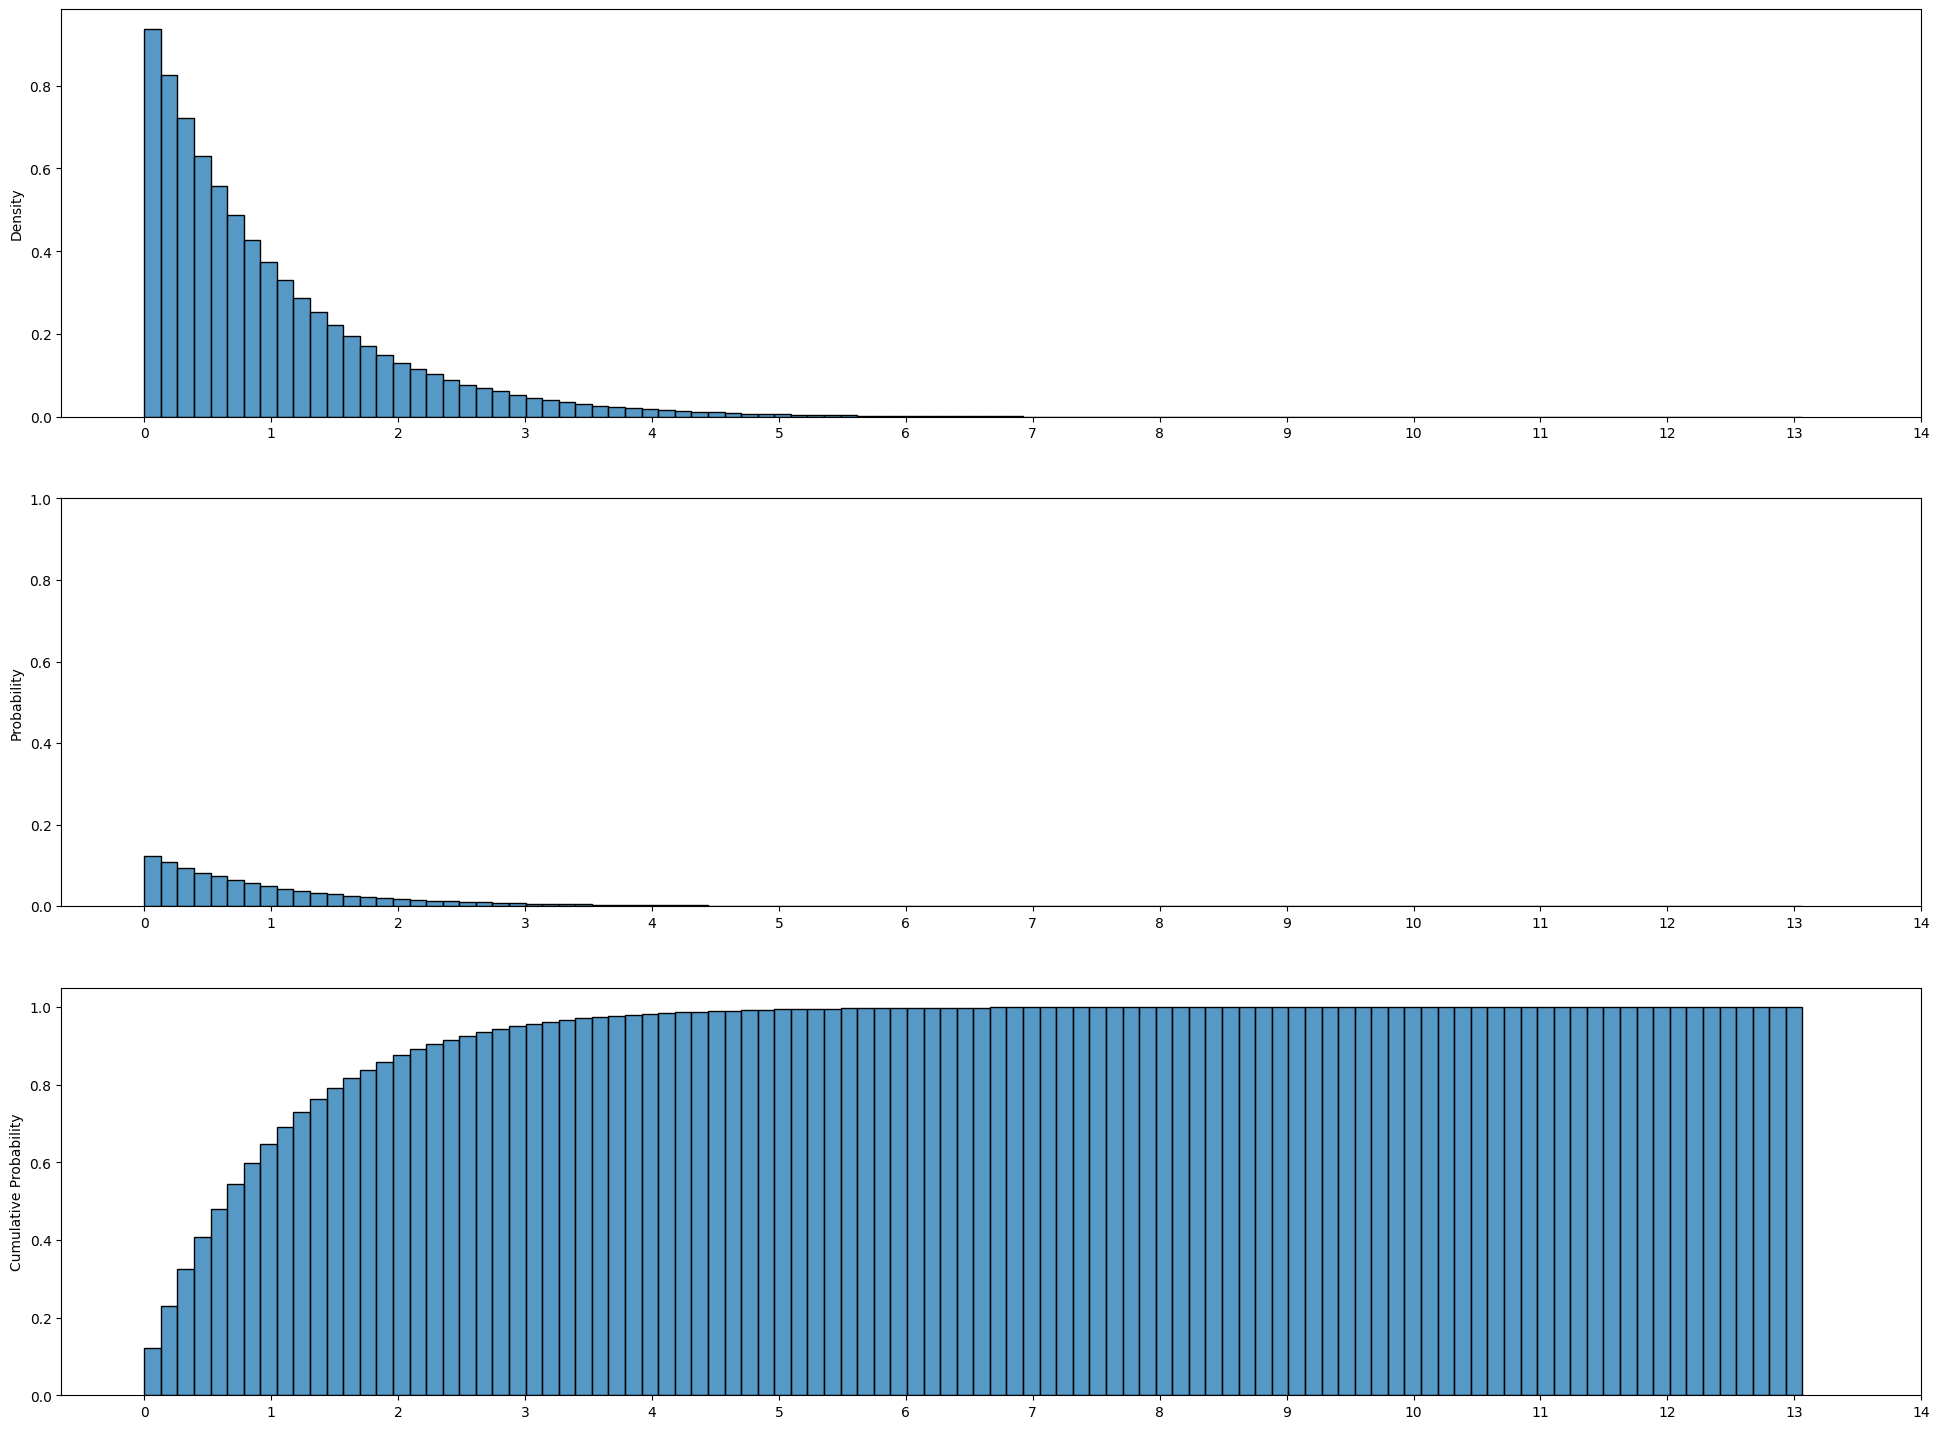

In [77]:
sample_from_exponential_hist(beta=1, sample_size=10**6)

Distribution seems familiar? This is because we may consinder Exponential Distribution as a coninuous generalization of Geometrical Distribution.

For RV $X\sim\mathcal{E}(\beta)$ we have its p.d.f, c.d.f and quantile function:

$$\varphi(x;\beta) = 
\begin{cases}
\frac{1}{\beta}e^{-x/\beta},\quad x\geqslant 0,\\
0,\quad x < 0.
\end{cases}
$$

$$\$$

$$F(x;\beta) = 
\begin{cases}
1 - e^{-x/\beta},\quad x\geqslant 0,\\
0,\quad x < 0.
\end{cases}
$$

$$\$$

$$Q(p;\beta) = -\beta\ln(1 - p).$$

#### SciPy-stuff

For Exponential Distribution we use `expon` object from `scipy.stats` module, along with corresponding methods.

In [78]:
from scipy.stats import expon

Sampling from $\mathcal{E}(1/3)$:

In [79]:
expon.rvs(scale=1/3, size=100)

array([2.19618748e-03, 3.64375205e-01, 1.04809161e-01, 2.12450652e-01,
       3.73176187e-01, 3.66999920e-03, 7.22287655e-02, 3.16579992e-02,
       1.45607905e-03, 5.91668074e-01, 1.31248753e-01, 4.32980244e-01,
       5.59229735e-01, 8.57164610e-01, 1.33437390e-01, 5.44188298e-01,
       5.84374622e-01, 1.90418529e-01, 6.95360779e-01, 2.05304006e-01,
       5.55755163e-02, 1.99793539e-01, 1.95186604e-01, 5.98995671e-01,
       1.87424627e+00, 4.81461814e-01, 1.46823435e-01, 3.10981370e-01,
       6.86519855e-01, 1.21064419e+00, 7.05709136e-02, 2.46536162e-01,
       1.08678087e+00, 4.12868090e-02, 2.06630676e-01, 1.75323750e-01,
       3.44325725e-01, 4.20362372e-01, 8.62999376e-02, 3.20127906e-01,
       7.62637404e-02, 2.98894100e-02, 2.91175454e-01, 5.89000010e-01,
       1.64717681e-01, 3.44108925e-02, 2.79888037e-01, 1.13176665e-02,
       4.21432905e-01, 9.35050357e-03, 5.56279730e-02, 1.40721401e-01,
       9.59375946e-01, 7.13971417e-02, 4.64532623e-01, 1.74926626e-01,
      

*It's a busy day and we are receiving, on average, 35 messages per hour. What's the probability of not getting any message in 15 minutes interval?*

We need to calculate 

$$P(X > 0.25) = 1 - P(X\leqslant 0.25) = 1 - F(0.25),$$

where $X\sim\mathcal{E}\big(\frac{1}{35}\big)$.

In [80]:
1 - expon.cdf(x=.25, scale=1/35)

np.float64(0.00015846132511576627)

*Let's get back to our particle decay. What's the half-life of a particle with an average lifetime of $\beta = 1$?*

For a population of particles, *half-life* is time interval within which a half of the particles in the population is expected to decay. In case you are telling to yourself that you didn't come to this course to do nuclear physics, all is fine - here you just need to do something you might be doing quite often in your job: compute the median. In this case a median for a population with $\mathcal{E}(1)$ distribution. And you don't need to really calculate it - SciPy can do it for you, using quantile function:

In [81]:
expon.ppf(q=.5, scale=1)

np.float64(0.6931471805599453)

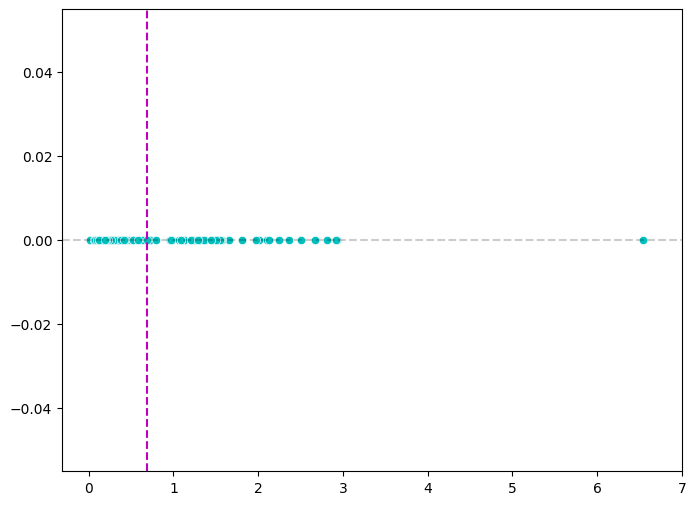

In [82]:
sample = sample_from_exponential_scatter(beta=1, sample_size=10**2, perc=.5)

In [83]:
len(sample[sample < 0.6931])/len(sample)

0.55

*Note*: Quite often Exponential Distribution is given by its *rate parameter* $\lambda$ which is the inverse of scale parameter $\beta$, i.e. $\lambda = \frac{1}{\beta}$.

### Normal (Gaussian) Distribution

Ah, the queen of distributions: well-known Normal Distribution with its so-called 'bell curve', loved and used both natural and social scientists alike. One of its main usages is using it as a distribution for random variables that have unknown distributions. This is the consequence of *Central Limit Theorem* which, loosely speaking, says that if we take a sample large enough, from a population with unknown distribution, we can approximate that distribution by Normal Distribution using the sample's mean and variance... under certain conditions of course. 

Normal Distribution, denoted by $\mathcal{N}(\mu, \sigma^2)$, has two parameters:

- $\mu$: *mean*, which dictates the peak of the bell-curve, i.e. a point which neighbourhood should be most densly populated by samples;

- $\sigma$: *standard deviation*, which dictates the thickness of the bell-curve, i.e. the dispersion of the sample away from the mean.

$\sigma^2$ which appears in the notation above is called *variance*.

We're going to plot p.d.f. and c.d.f of Normal Distribution by sampling. To sample from a population with Normal Distribution we use `rng.normal()` with arguments `loc` for $\mu$ and `scale` for $\sigma$.

*Average height of some population is 176cm with standard deviation of 6cm. Assuming that the height in this population is normally distributed, plot the heights from a random sample drawn from this population.*

We sample from $\mathcal{N}(176, 36)$.

In [84]:
def sample_from_normal_scatter(mu, sigma, sample_size=10**2):
    
    sample = rng.normal(loc=mu, scale=sigma, size=sample_size)

    fig, ax = plt.subplots(figsize=(16, 8))

    sns.scatterplot(x=sample, y=0, color='c')

    ax.axhline(0, c='k', linestyle='--', alpha=.2)
    
    ax.set_xticks(np.arange(round(sample.min()), sample.max() + 2, 2));

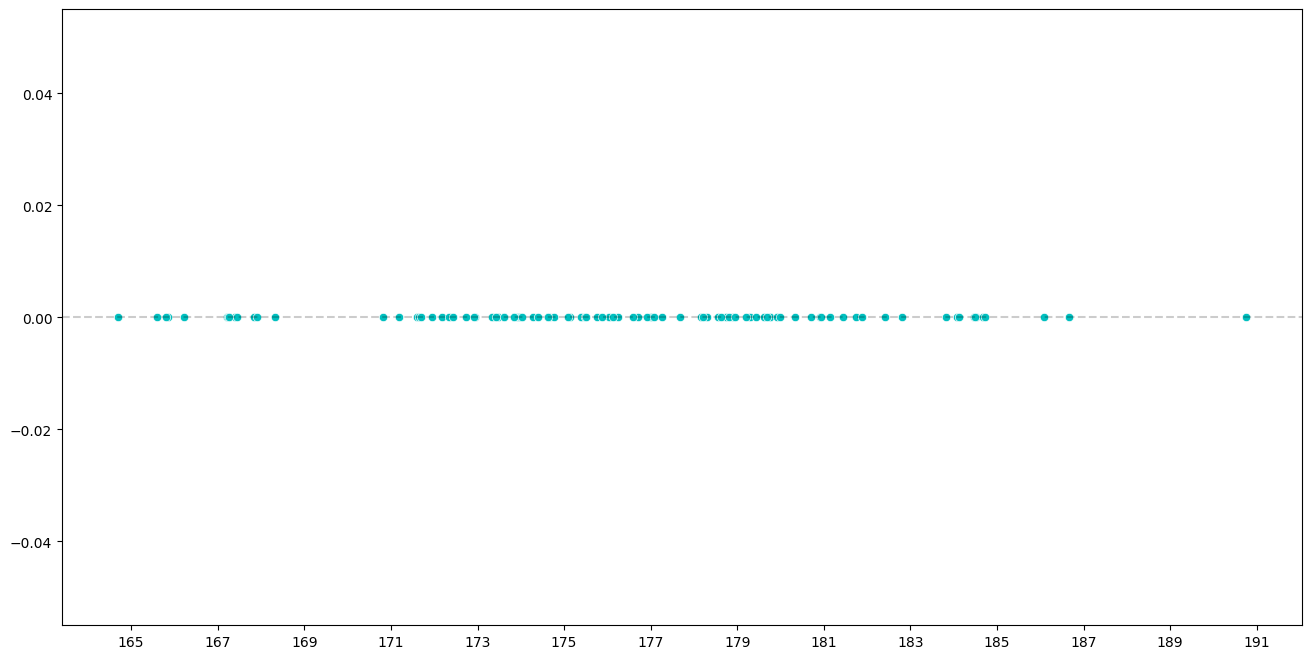

In [85]:
sample_from_normal_scatter(mu=176, sigma=6, sample_size=10**2)

In [86]:
def sample_from_normal_hist(mu, sigma, sample_size=10**3):
    
    fig, ax = plt.subplots(3, 1, figsize=(24, 18))
    
    sample = rng.normal(loc=mu, scale=sigma, size=sample_size)
    
    sns.histplot(ax=ax[0], x=sample, bins=100, stat='density')
    sns.histplot(ax=ax[1], x=sample, bins=100, stat='probability')
    sns.histplot(ax=ax[2], x=sample, bins=100, stat='probability', cumulative=True)
    
    ax[0].axvline(mu, c='r')
    
    ax[0].axvline(mu - sigma, c='g', linestyle='--')
    ax[0].axvline(mu + sigma, c='g', linestyle='--')
    
    ax[0].axvline(mu - 2*sigma, c='g', linestyle='--', alpha=.5)
    ax[0].axvline(mu + 2*sigma, c='g', linestyle='--', alpha=.5)
    
    ax[0].axvline(mu - 3*sigma, c='g', linestyle='--', alpha=.25)
    ax[0].axvline(mu + 3*sigma, c='g', linestyle='--', alpha=.25)

    
    ax[0].set_xticks(np.arange(round(sample.min()) - 1, sample.max() + sigma, sigma))
    ax[1].set_xticks(np.arange(round(sample.min()) - 1, sample.max() + sigma, sigma))
    ax[2].set_xticks(np.arange(round(sample.min()) - 1, sample.max() + sigma, sigma))
    
    ax[1].set_yticks(np.arange(0, 1.2, .2))
    
    ax[2].set_ylabel('Cumulative Probability')

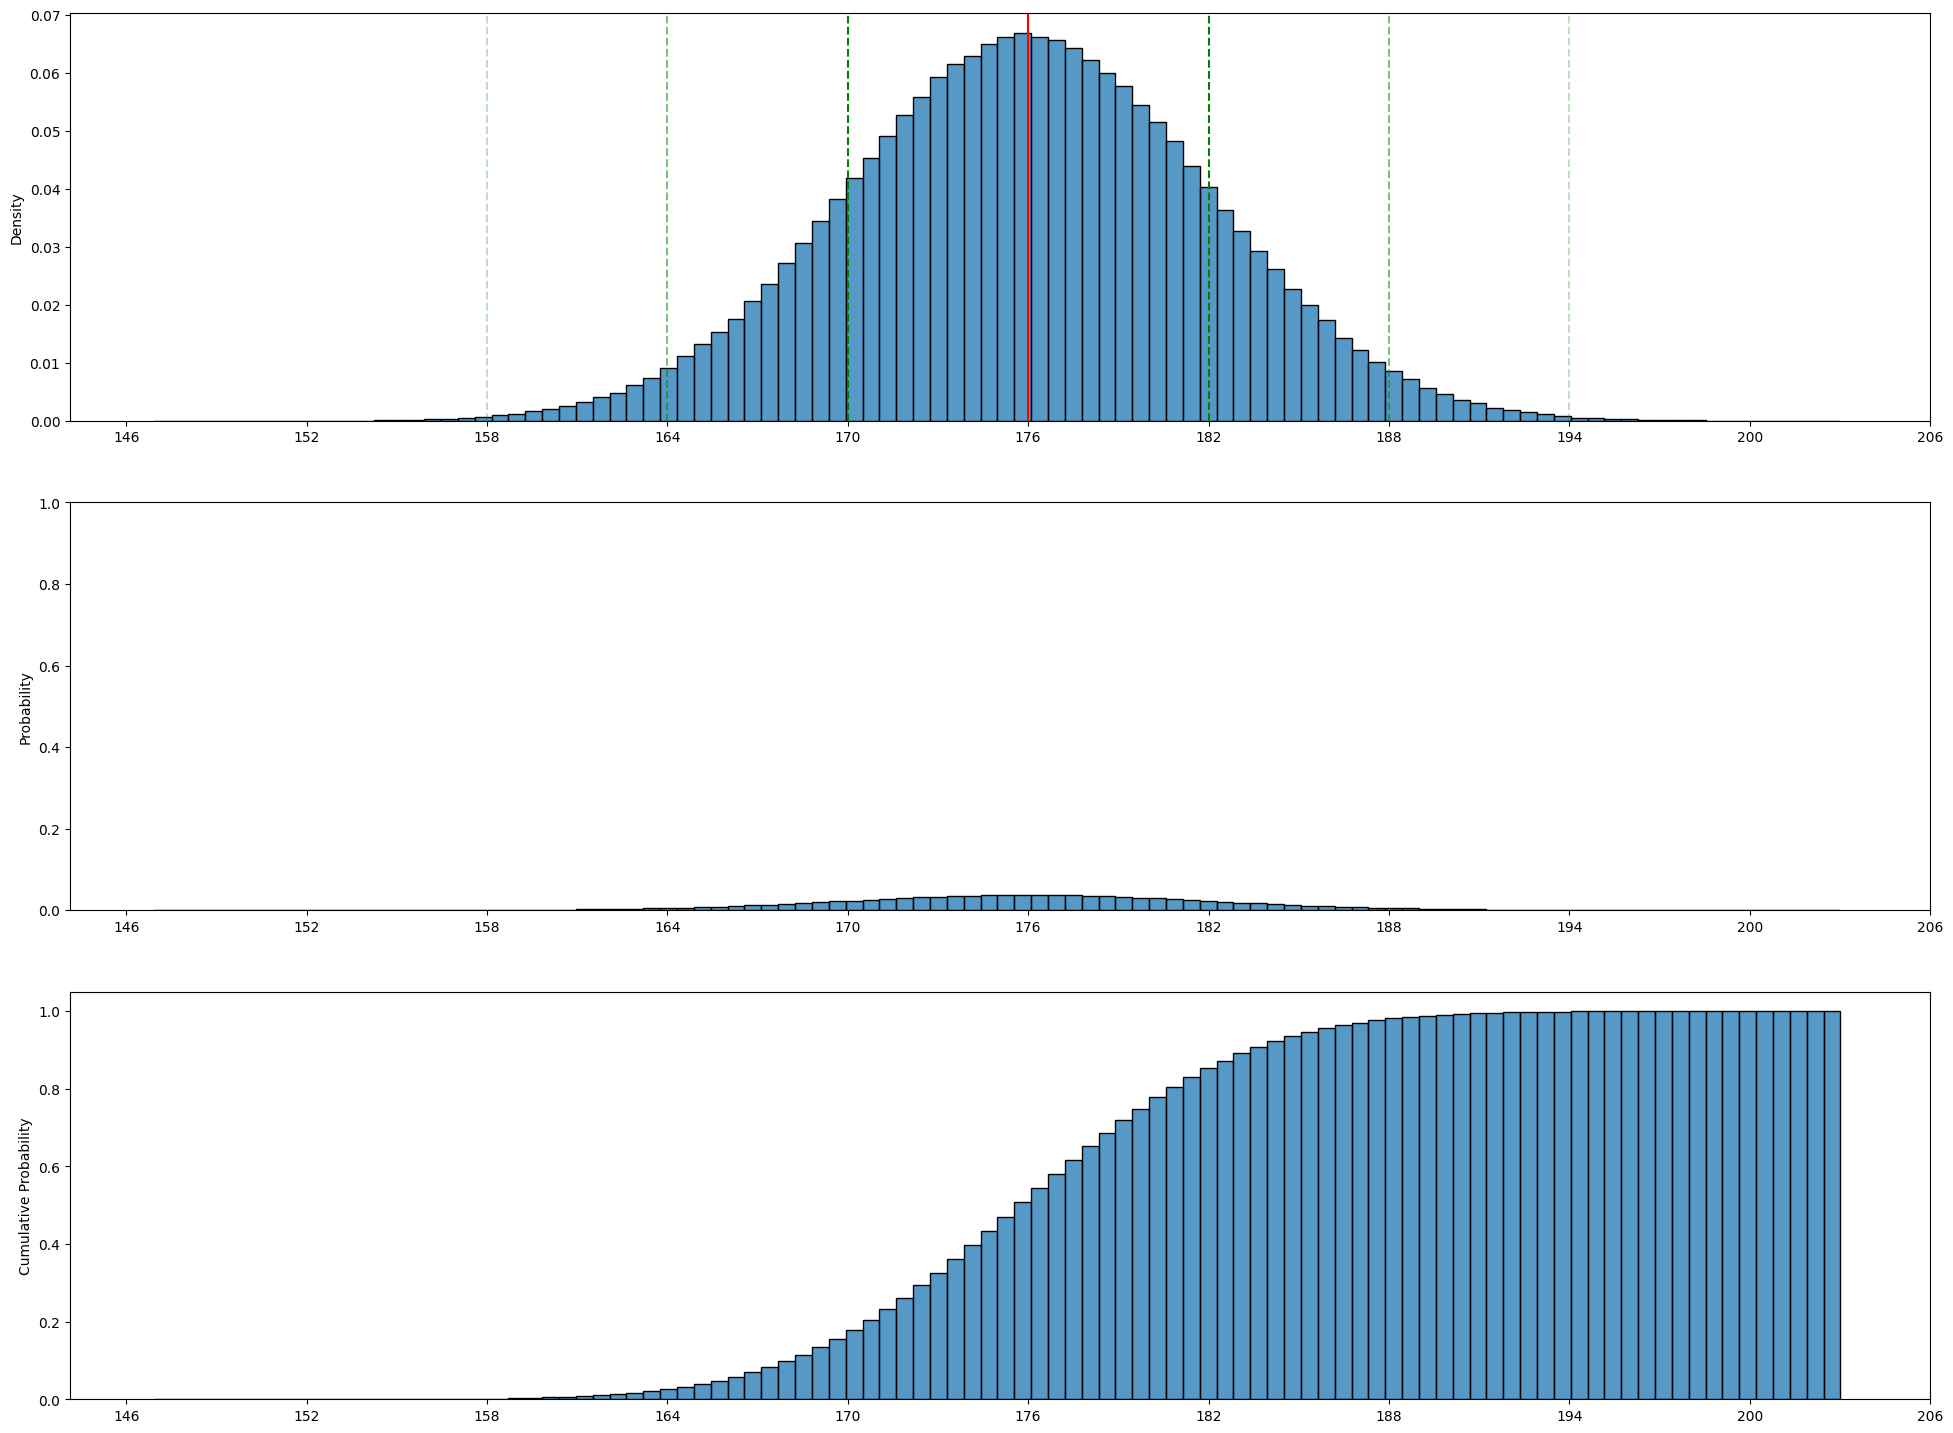

In [87]:
sample_from_normal_hist(mu=176, sigma=6, sample_size=10**6)

The p.d.f for RV with Normal Distribution $X\sim\mathcal{N}(\mu, \sigma^2)$ is given by

$$\varphi(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\big(\frac{x-\mu}{\sigma}\big)^2}.$$

A very special Normal Distribution is the one with $\mathcal{N}(0, 1)$, and it's called *Standard Normal Distribution*. Its p.d.f. and c.d.f. are

$$\varphi(z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}}$$

$$\$$

$$\Phi(z) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^ze^{-\frac{x^2}{2}}dx.$$

It's integrals again... shouldn't c.d.f relieve us of calculating integrals? Well, yes, but there's no simpler way to represent c.d.f for Standard Normal Distribution. Luckily, every statistics and probability textbook has a table of values of $\Phi(z)$ for various values of $z$. 

Looking at one of those tables we obtain, for $Z\sim\mathcal{N}(0, 1)$, 

$$\Phi(-2.27) = P(Z < -2.27) = 0.0116.$$

We can plot p.d.f and c.d.f. by sampling from such $Z$:

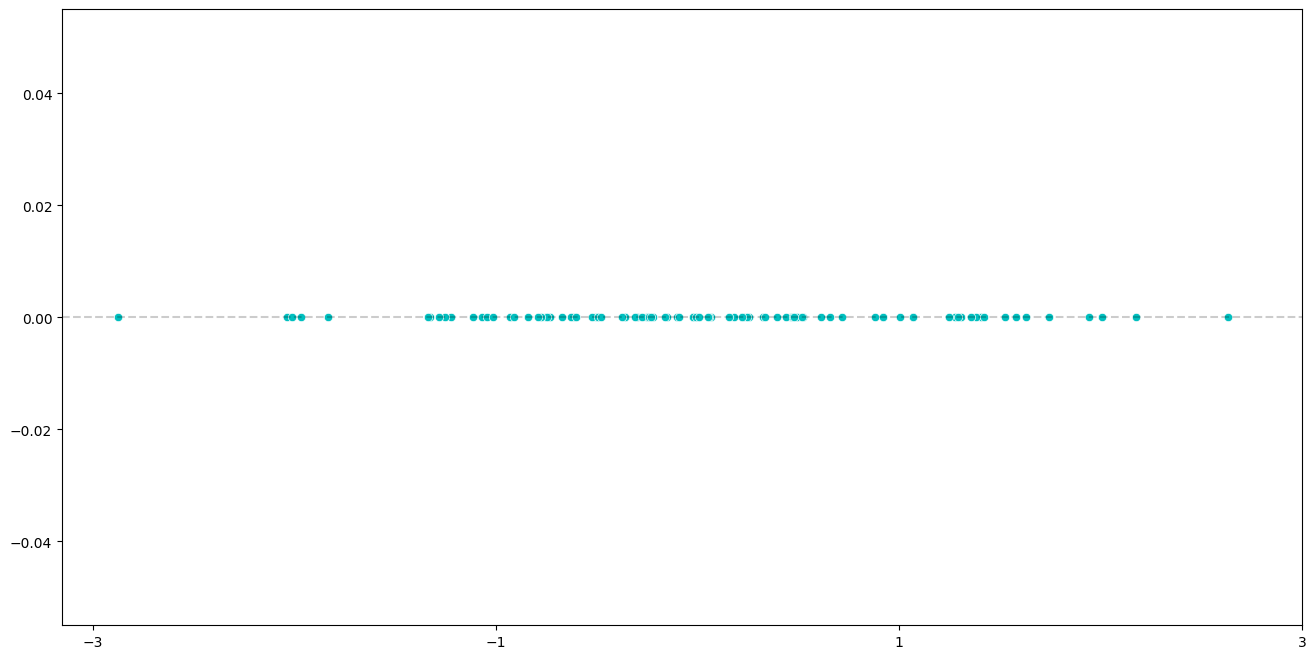

In [88]:
sample_from_normal_scatter(mu=0, sigma=1, sample_size=100)

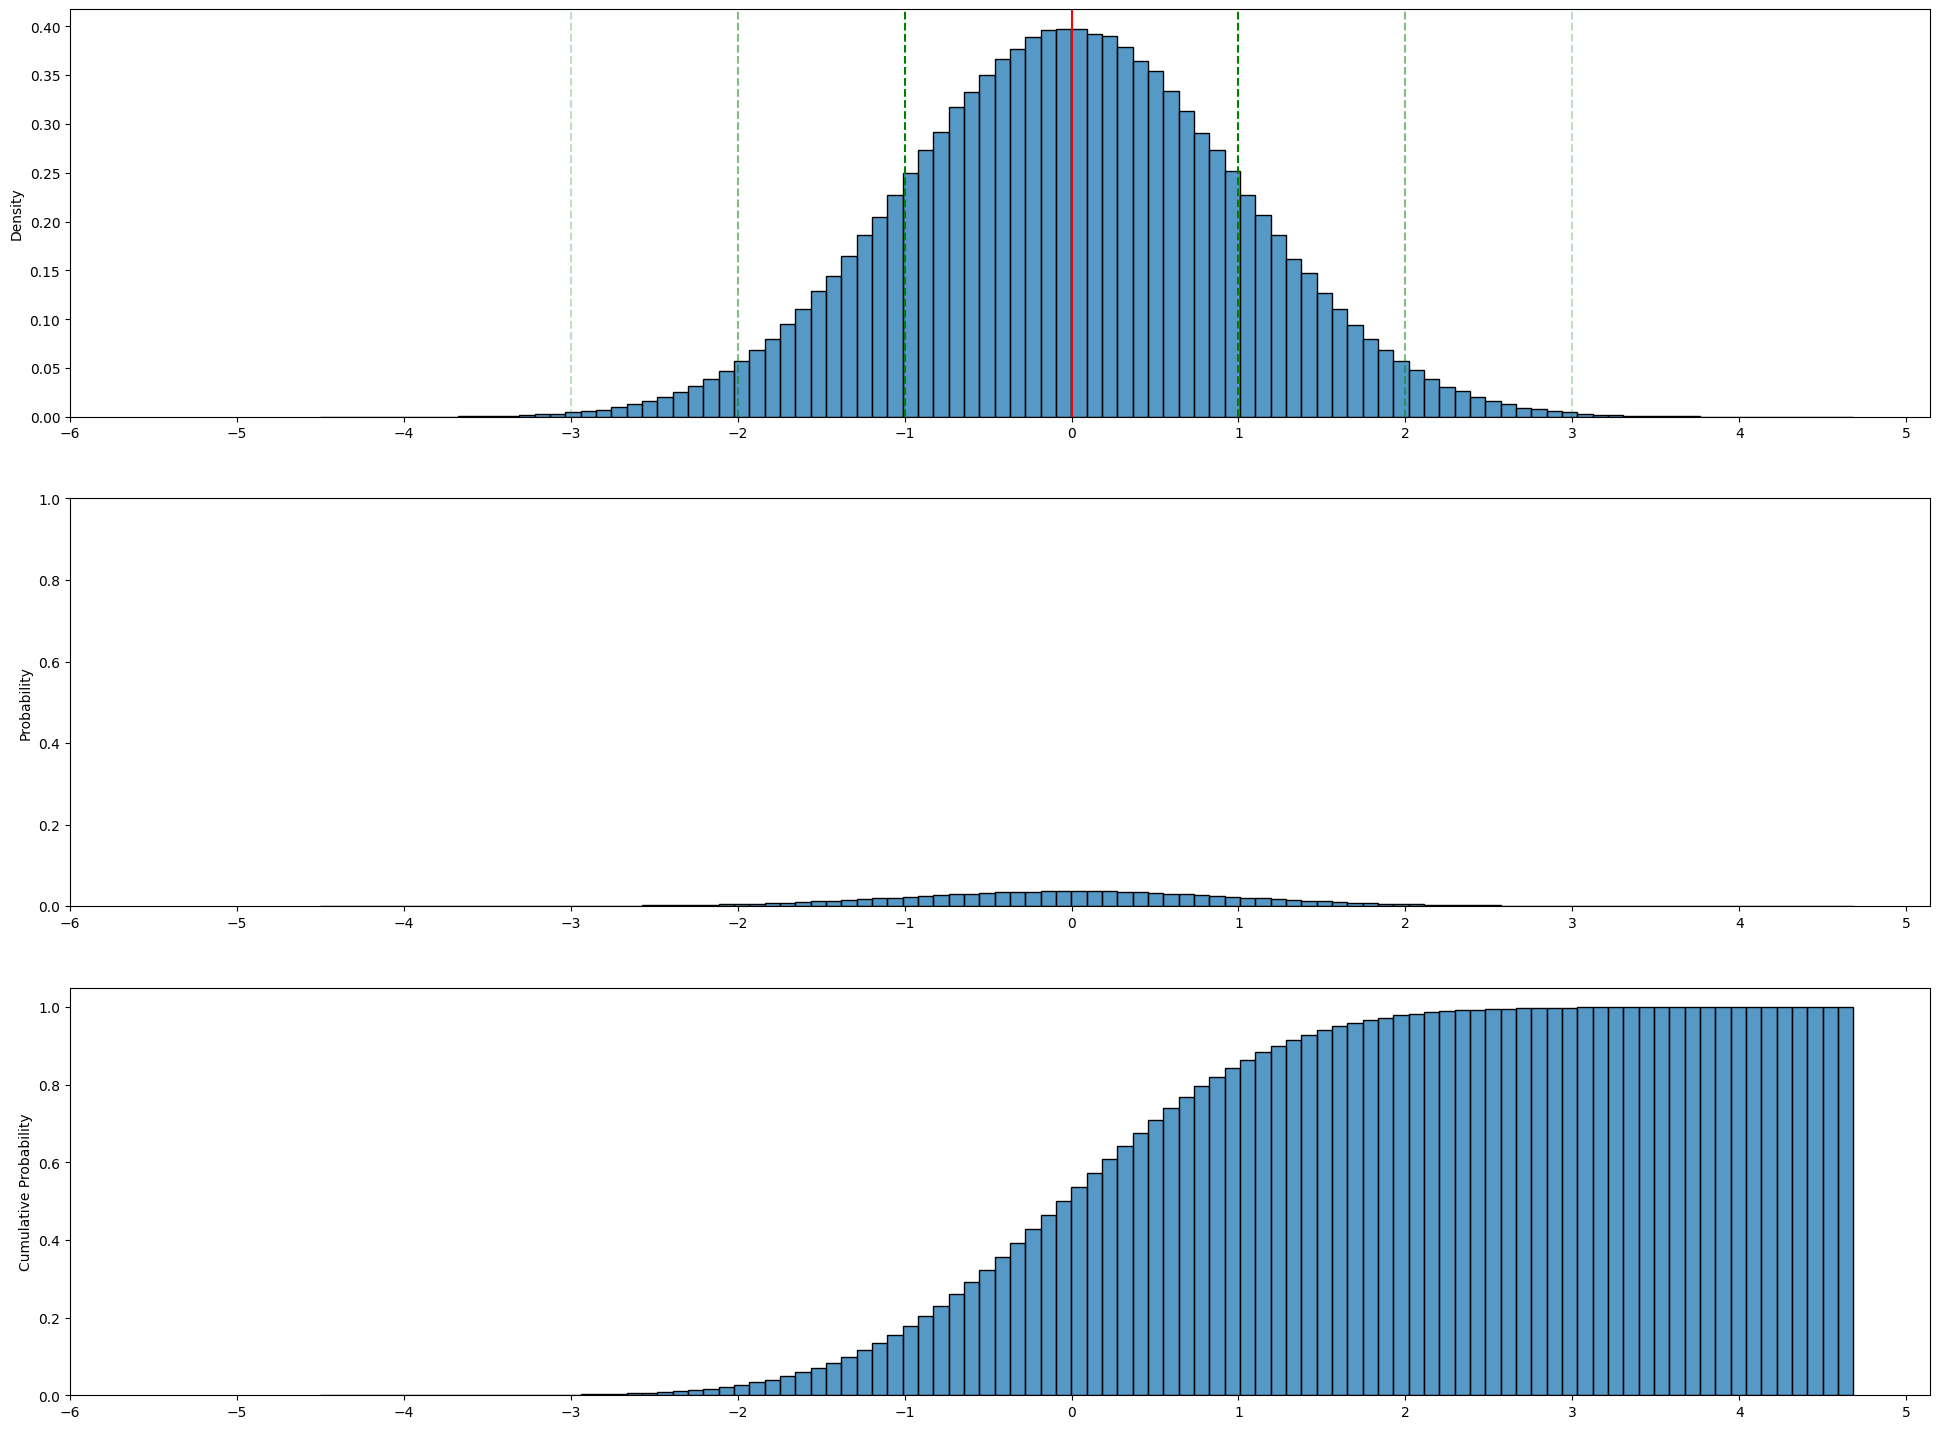

In [89]:
sample_from_normal_hist(mu=0, sigma=1, sample_size=10**6)

*Average time for delivery service to deliver food is 30 minutes, with standard deviance of 10 minutes. Asuming the time for delivery is random variable with Normal Distribution, find probability of your order arriving more than five minutes late than average.*

We have $X\sim\mathcal{N}(30, 100)$ and calculate

$$P(X > 35) = 1 - P(X\leqslant 35).$$

But wait, we don't have c.d.f. for this Normal Distribution, because it's not standard. Worry not, we can *standardize* a RV $X\sim\mathcal{N}(\mu, \sigma)$ by applying the following transformation

$$Z = \frac{X - \mu}{\sigma}.$$

RV $Z$ has the Standard Normal Distribution, and we can finde the value of its c.d.f. form the table. So, we continue our calculation:

$$P(X > 35) = 1 - P(X\leqslant 35) = 1 - P\Big(\frac{X - 30}{10}\leqslant  \frac{35 - 30}{10}\Big) = 1 - P(Z\leqslant 0.5) = 1 - \Phi(0.5) = 1 - 0.6915 = 0.3085.$$

Do we really need even to look at the table. No, if you have SciPy:)

#### Sci-py stuff

For Normal Distribution we use `norm` object from `scipy.stats` module, along with corresponding methods.

In [90]:
from scipy.stats import norm

To compute the probability above, we just do the following:

In [91]:
1 - norm.cdf(x=.5)

np.float64(0.3085375387259869)

We don't even need to standardize the RV, we can just pass `loc` and `scale` arguments in `.cdf()` method for $\mu$ and $\sigma$, respectively:

In [92]:
1 - norm.cdf(x=35, loc=30, scale=10)

np.float64(0.3085375387259869)

Getting back to our height example: *what's the height below which we are to expect to find 5% population from the sample?* This requires qantile function. If you remember, we have for our RV $\mathcal{N}(176, 36)$, so we compute: 

In [93]:
norm.ppf(q=.05, loc=176, scale=6)

np.float64(166.13087823829116)

## R2.8 Mathematical Expectation and Mathematical Variance

In a previous example for food delivery, we said that the average time for the delivery to happen is 30 minutes. Intuitivelly, you are going to *expect* your delivery in some thirty minutes. Is this *(mathematical) expectation* (or *expected value*) some kind of 'average' of a random variable? Is the average value of a sample drawn from a distribution equal to the expected value of the distribution? Generally it isn't. But it could be almost equal. If the sample is big enough. 

The difference between average of a sample and an expected value of a distribution is the difference between *sample mean* and *theoretical mean*. We're going to further illuminate this difference later on; but first, let's define mathematical expectation of a random variable more formally.

### Expectation for Discrete-type Random Variable

Let $X$ be a discrete-type RV

$$ X :
\begin{pmatrix}
a_1 & a_2 & \cdots & a_n\\
p_1 & p_2 & \cdots & p_n 
\end{pmatrix}.
$$

Its expected value $EX$ is calculated as:

$$EX = a_1p_1 + a_2p_2 + \cdots + a_np_n.$$

If RV $X$ takes infinite values, then this sum is infinite. 

For rolling a six-sided die we have a distribution

$$ X :
\begin{pmatrix}
1 & 2 & 3 & 4 & 5 & 6\\
\frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6}
\end{pmatrix},
$$

and its expected value is

$$EX = \frac{1+2+3+4+5+6}{6} = \frac{21}{6} = 3.5 .$$

Let's roll some dices again. We roll a die 10 times and compute its mean value. This is how we get sample mean $\bar{X}$. 

In [94]:
die = list(range(1, 7))

rolling = rng.choice(die, size=10)
rolling

array([2, 2, 5, 3, 6, 1, 4, 2, 6, 1])

In [95]:
rolling.mean()

np.float64(3.2)

Trying with more rolls...

In [96]:
rng.choice(die, size=100).mean()

np.float64(3.39)

In [97]:
rng.choice(die, size=10**6).mean()

np.float64(3.500451)

There it is: $\bar{X}$ *almost* equal to $EX$. And you've guessed it - we would have $\bar{X} = EX$ *exactly* if we rolled infinite amount of times. Thus we write

$$EX = \lim_{N\rightarrow\infty}\bar{X}_N =\lim_{N\rightarrow\infty}(X_1 + X_2 + \cdots + X_N).$$

So, sample mean approximates distribution mean when the sample is big enough. Or, in other words - expectation is *theoretical* mean, while the sample mean is *experimental* mean.

***

Many distributions have ready formula for their expected values, and some of them even use it as a parameter (say, $\lambda$ for Poission Distribution). Let's refresh on Binomial Distribution. For RV $X\sim\mathcal{B}(n, p)$ we have 

$$EX = np.$$

For tossing a coin 10 times, we have $X\sim\mathcal{B}(10, 0.5)$ and we expect to land Tails $EX = 10\cdot 0.5 = 5$ times. If we perofrm this experiment many times and plot the distribution of outcomes - we see the peak at 5. And we can also compute mean value of outcomes of all experiments: 

In [98]:
rng.choice([0, 1], size=10**6).mean()

np.float64(0.500489)

### Expectation for Continuous-type Random Variable

For a coninuous RV $X$ with p.d.f $\varphi(x)$ we compute its expected value with

$$EX = \int_{-\infty}^{+\infty}x\varphi(x)dx.$$

But don't worry - you don't need to compute this integral unless you reealy need; and you won't be doing that on this course, as the expectations of the distributions we're using are given in a formula.

For example, for Exponential Distribution $\mathcal{E}(\beta)$ we have 

$$EX = \beta.$$

So, if we receive, on average, 35 messages in one hour ($X\sim\mathcal{E}\big(\frac{1}{35}\big)$), the expected time to receive one message is, of course, $EX = 1/35 \approx 0.029$, some 1.74 minutes. Beautiful. But let's check this.

In [99]:
rng.exponential(scale=1/35, size=10**4).mean()

np.float64(0.02804241898865177)

Normal Distribution is another distribution which uses mean $\mu$ as a parameter.

### Variance

Variance is the *expected squared* deviation of a random variable from its mean. So, it's another expected value, and as such there exist *mathematical variance*, which is *theoretical* and sample variance, which is *experimental*.

Mathematical variance is computed using the formula:

$${\rm Var}(X) = E[(X - EX)^2].$$


Sample variance is computed using the formula:

$$s^2 = \frac{\sum\limits_{i=1}^{N}{(X_i - \bar{X})^2}}{N - 1},$$

where $N$ is the sample size and $\bar{X}$ is the sample mean.

For a sample big enough, sample variance approximates theoretical variance.

***

As for the expectation, there's no need to compute theoretical variance for frequently used distributions, as there is a formula. 

For Binomial Distribution $\mathcal{B}(n, p)$ we have

$${\rm Var}(X) = np(1-p).$$

Let's use this formula in our example for $\mathcal{B}(10, 0.5)$ (tossing a coin 10 times) to see how sample variance approximate theoretical variance. So, the theoretical value is

$${\rm Var}(X) = 10\cdot 0.5\cdot 0.5 = 2.5.$$

This means that we expect, when drawing a sample, to land Tails 5 $\pm$ 2.5 times in 10 tosses, most of the time. 

In [100]:
rng.choice([0, 1], size=10**3).var(ddof=1)

np.float64(0.2500540540540541)

Normal distribution uses the variance as the second parameter $\sigma$. For our population in the previous example with $\mathcal{N}(176, 36)$ we sample and compute the variance:

In [101]:
rng.normal(loc=176, scale=6, size=10**6).var(ddof=1)

np.float64(36.060009527492994)

#### SciPy-Stuff

We can find theoretical expectation and variance of a given distribution using `.stats()` method from the corresponding distribution in `scipy.stats` module.

For $\mathcal{B}(10, 0.5)$ we compute

In [102]:
from scipy.stats import binom

In [103]:
binom.stats(n=10, p=.5)

(np.float64(5.0), np.float64(2.5))

For $\mathcal{N}(176, 36)$ we get

In [104]:
norm.stats(loc=176, scale=6)

(np.float64(176.0), np.float64(36.0))

(Who would say?...)

### Further Reading:

[https://www.khanacademy.org/math/statistics-probability/probability-library](https://www.khanacademy.org/math/statistics-probability/probability-library)

[Random variables | Statistics and probability | Math | Khan Academy]( https://www.khanacademy.org/math/statistics-probability/random-variables-stats-library)

***
> **Bridge — from one draw to many samples.** Every section so far has described a *single* random draw from a distribution. But an analyst almost never sees the whole population; you see a **sample**, and you report its **mean**. The final two sections ask the question that silently underpins every confidence interval and p-value in Sessions 01–03: *how does the sample mean behave when you draw sample after sample?* The answer — the **sampling distribution of the mean** and the **Central Limit Theorem** — is the statistical backbone of the entire course. (These two sections are translated to Python from the R edition of this material.)

***
## R2.9 The sampling distribution of the sample mean

Let us assume some quantity in reality follows a Normal distribution with $\mu = 100$ and $\sigma = 12$, and draw *many, many* random samples of size 100 from it — each time keeping only the **mean** of the sample. The collection of those means has a distribution of its own: the **sampling distribution of the sample mean**.

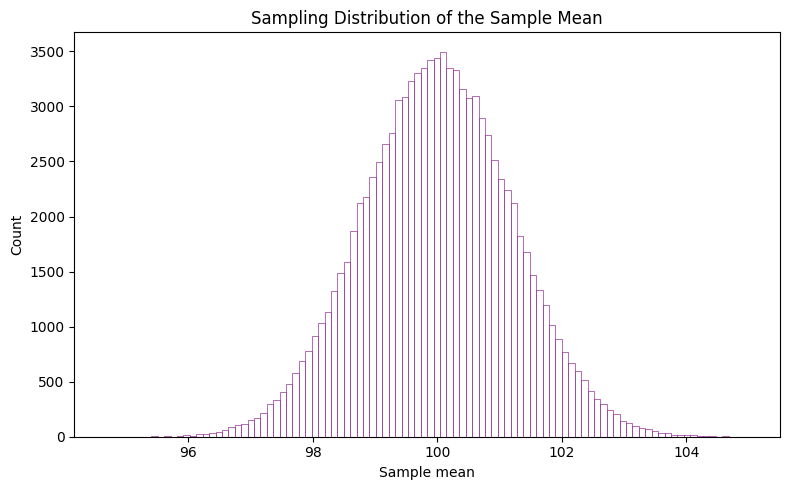

In [105]:
# We treat Normal(mu=100, sigma=12) as the "true" population.
# Draw 100,000 samples, each of size 100, and keep only each sample's MEAN.
rng = np.random.default_rng(seed=1023)

n_samples = 100_000
sample_means = np.array([
    rng.normal(loc=100, scale=12, size=100).mean()
    for _ in range(n_samples)
])

# Plot the distribution of those 100,000 sample means.
plt.figure(figsize=(8, 5))
sns.histplot(sample_means, bins=100, color="white", edgecolor="purple")
plt.title("Sampling Distribution of the Sample Mean")
plt.xlabel("Sample mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**What we see.** A clean bell shape, tightly centred on the true mean of 100 — even though each individual sample was only 100 draws. Now the key question: **how wide is this distribution?**

In [106]:
# The standard deviation of the sample means IS the standard error of the mean.
sample_means.std(ddof=1)

np.float64(1.1980452505933425)

Recall that the population standard deviation was $\sigma = 12$. Compare the number above with $\sigma / \sqrt{N}$, where $N = 100$ is the size of each sample:

In [107]:
12 / np.sqrt(100)

np.float64(1.2)

The two numbers are essentially identical. This is one of the most important facts in all of statistics. The standard deviation of the sampling distribution of the mean — called the **standard error** — equals the population standard deviation divided by $\sqrt{N}$:

$$\sigma_{\bar{x}} \;=\; \frac{\sigma}{\sqrt{N}}$$

A word on vocabulary, because these two are constantly confused:

- **Standard deviation (SD)** measures the dispersion of a *dataset* around its own mean — how spread out the raw values are.
- **Standard error of the mean (SEM)** measures how much a *sample's mean* is likely to differ from the true population mean. It takes the SD and divides it by $\sqrt{N}$.

The practical payoff: **the more data you collect, the smaller the standard error** — but only as $\sqrt{N}$, so halving your uncertainty requires *four times* the sample. This is exactly the $\sqrt{N}$ law you met in Session 01 (§1.10) and Session 02 (§2.11), now derived from first principles.

***
## R2.10 The Central Limit Theorem

Section R2.9 drew samples from a Normal population and got a Normal-looking distribution of means — perhaps unsurprising, since we started Normal. The **Central Limit Theorem (CLT)** makes a far stronger claim: *no matter what distribution you start from* — skewed, discrete, lumpy — the distribution of the sample mean tends toward a **Normal** distribution as you take more and more samples.

We will demonstrate it numerically. The recipe each time:

1. pick a distribution (Normal, Poisson, or Binomial) with fixed parameters;
2. draw a random sample of size `sample_n = 100`;
3. compute the mean of that sample;
4. repeat step 2–3 either 10, 100, 1,000, or 10,000 times;
5. plot a histogram of the means we collected.

In [108]:
# Fixed sample size; we vary the NUMBER of samples we average.
sample_n = 100
mean_sizes = [10, 100, 1000, 10000]

# Helper: for each count in `mean_sizes`, draw that many sample means
# (each from a sample of size `sample_n` produced by `sampler`) and show a 2x2 grid.
def clt_grid(sampler, mean_sizes, sample_n, color, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(9, 7))
    for ax, n_means in zip(axes.ravel(), mean_sizes):
        means = np.array([sampler(sample_n).mean() for _ in range(n_means)])
        ax.hist(means, bins=50, color=color)
        ax.set_title(f"N samples = {n_means}", fontsize=9)
    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()

We start with the **Poisson** distribution, which for small $\lambda$ is strongly right-skewed — about as far from a bell curve as we can easily get. Poisson with $\lambda = 1$:

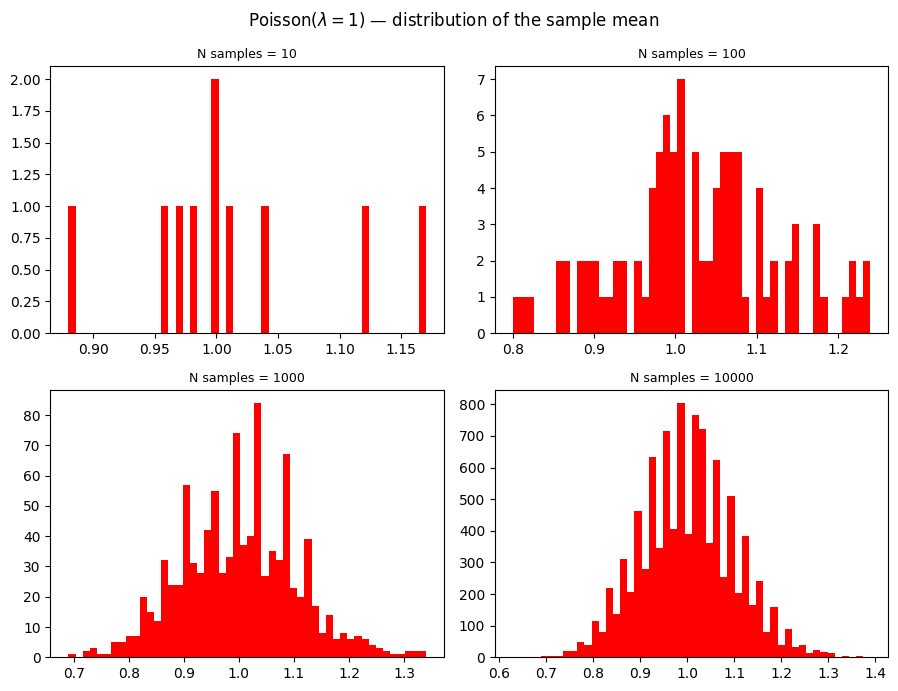

In [109]:
clt_grid(lambda n: rng.poisson(lam=1, size=n), mean_sizes, sample_n, "red",
         r"Poisson($\lambda=1$) — distribution of the sample mean")

Poisson with $\lambda = 2$:

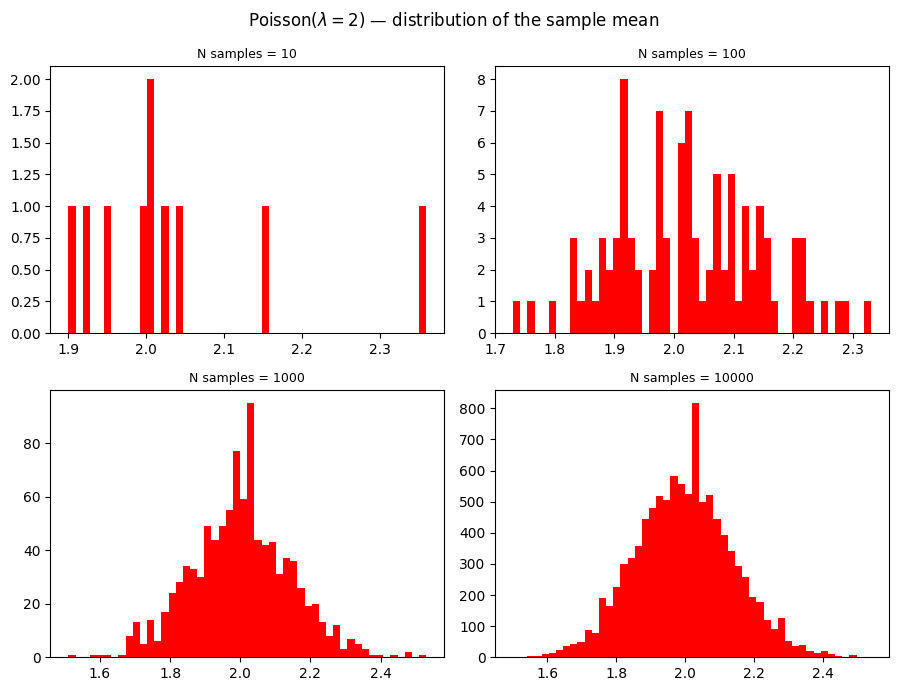

In [110]:
clt_grid(lambda n: rng.poisson(lam=2, size=n), mean_sizes, sample_n, "red",
         r"Poisson($\lambda=2$) — distribution of the sample mean")

Poisson with $\lambda = 10$:

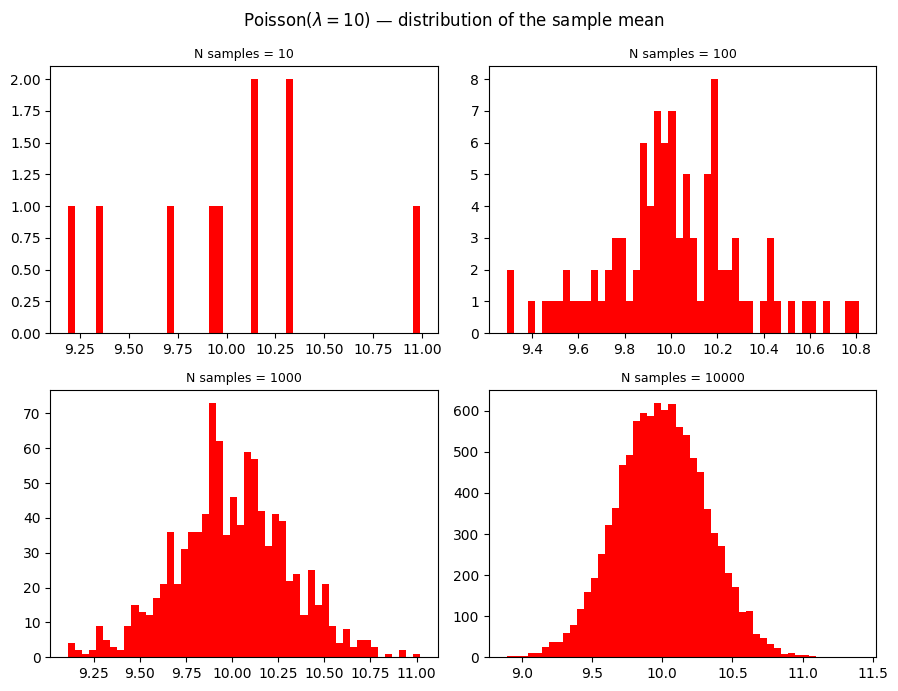

In [111]:
clt_grid(lambda n: rng.poisson(lam=10, size=n), mean_sizes, sample_n, "red",
         r"Poisson($\lambda=10$) — distribution of the sample mean")

Now the **Binomial**. Binomial with $n = 1000$ and $p = 0.1$:

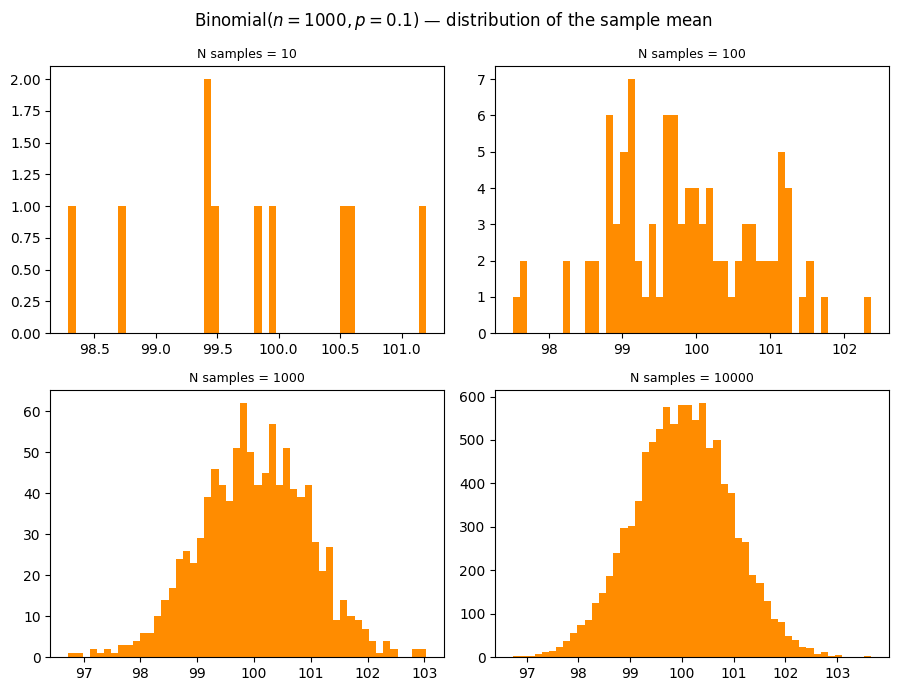

In [112]:
clt_grid(lambda n: rng.binomial(n=1000, p=0.1, size=n), mean_sizes, sample_n, "darkorange",
         r"Binomial($n=1000, p=0.1$) — distribution of the sample mean")

Binomial with $n = 1000$ and $p = 0.5$:

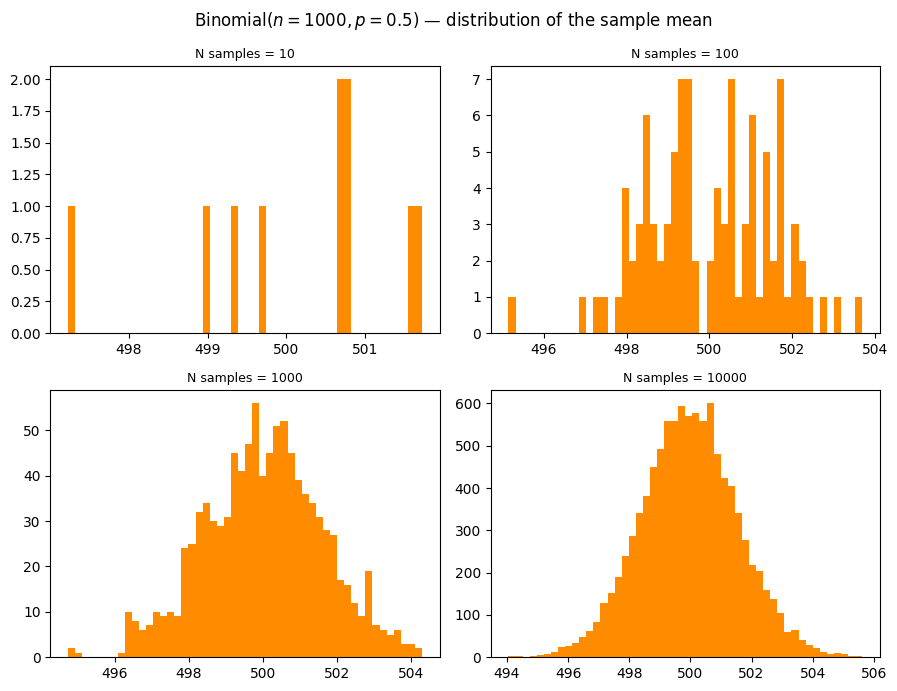

In [113]:
clt_grid(lambda n: rng.binomial(n=1000, p=0.5, size=n), mean_sizes, sample_n, "darkorange",
         r"Binomial($n=1000, p=0.5$) — distribution of the sample mean")

And the **Normal**, as a control. Normal with $\mu = 10$ and $\sigma = 1.5$:

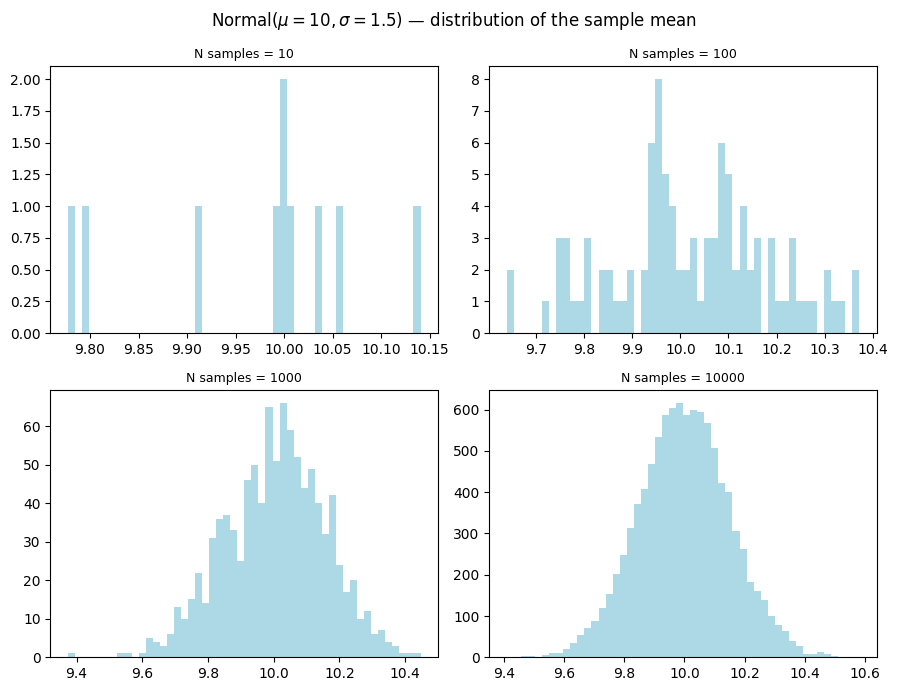

In [114]:
clt_grid(lambda n: rng.normal(loc=10, scale=1.5, size=n), mean_sizes, sample_n, "lightblue",
         r"Normal($\mu=10, \sigma=1.5$) — distribution of the sample mean")

Normal with $\mu = 175$ and $\sigma = 11.4$:

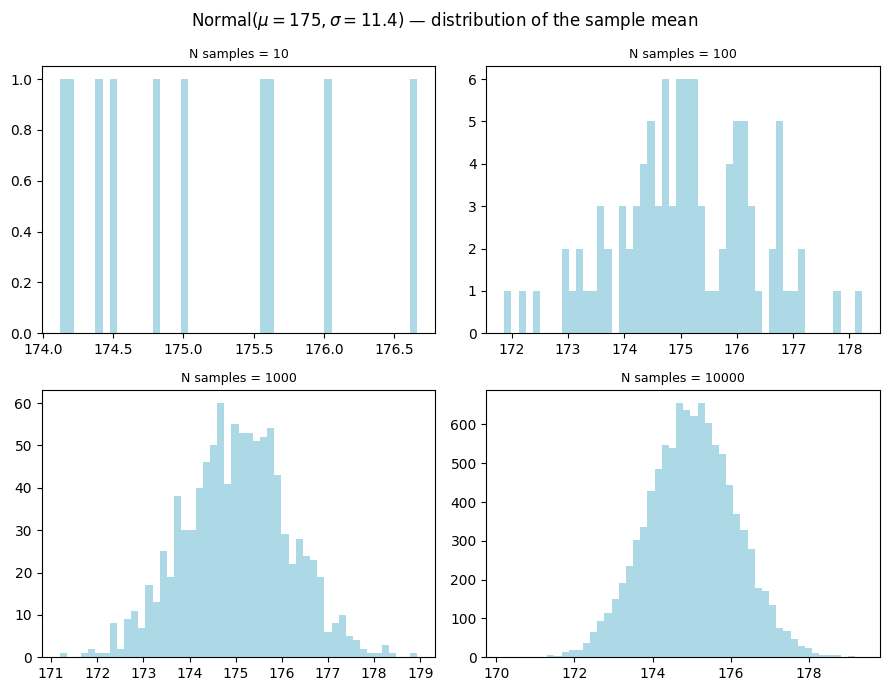

In [115]:
clt_grid(lambda n: rng.normal(loc=175, scale=11.4, size=n), mean_sizes, sample_n, "lightblue",
         r"Normal($\mu=175, \sigma=11.4$) — distribution of the sample mean")

Normal with $\mu = 100$ and $\sigma = 25$:

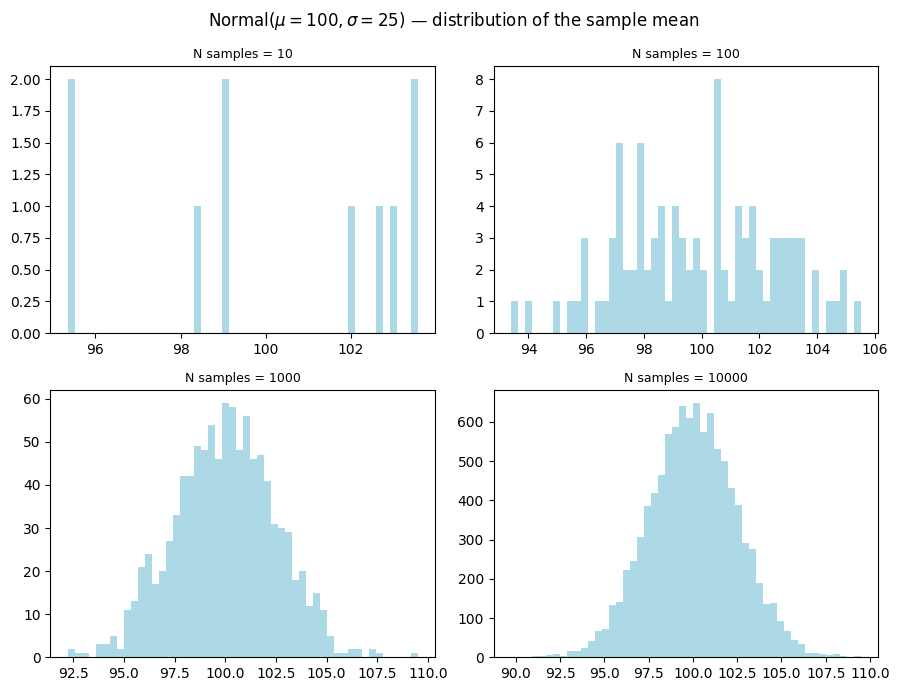

In [116]:
clt_grid(lambda n: rng.normal(loc=100, scale=25, size=n), mean_sizes, sample_n, "lightblue",
         r"Normal($\mu=100, \sigma=25$) — distribution of the sample mean")

**What we see across all of these.** As the number of samples grows (top-left to bottom-right in each grid), the histogram of sample means fills in toward the **same bell shape** — whether the parent distribution was a skewed Poisson, a Binomial, or a Normal. *The shape of the parent distribution stops mattering.* That is the Central Limit Theorem showing up on its own.

Now a second experiment: instead of varying the *number* of samples, we hold that fixed at 10,000 and increase the **sample size** $N$ itself.

In [117]:
# This time: fix the number of sample means at 10,000, and vary the SAMPLE SIZE.
sample_sizes = [10, 100, 1000, 100000]
n_means_fixed = 10000

def clt_grid_by_size(sampler, sample_sizes, n_means, color, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(9, 7))
    for ax, s_n in zip(axes.ravel(), sample_sizes):
        means = np.array([sampler(s_n).mean() for _ in range(n_means)])
        ax.hist(means, bins=50, color=color)
        ax.set_title(f"Sample size = {s_n}", fontsize=9)
    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()

Poisson with $\lambda = 3$, as the sample size grows:

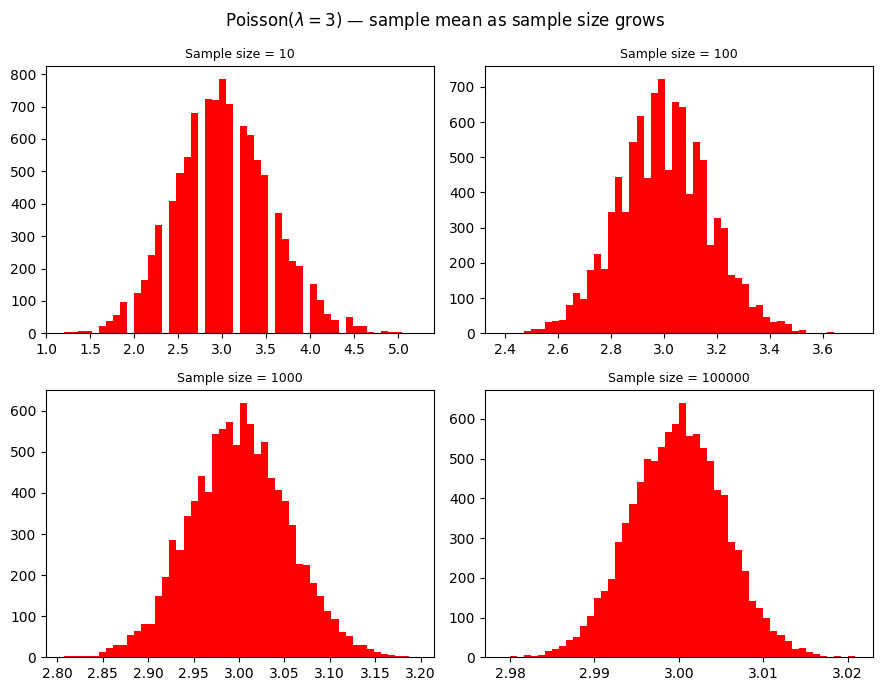

In [118]:
clt_grid_by_size(lambda n: rng.poisson(lam=3, size=n), sample_sizes, n_means_fixed, "red",
                 r"Poisson($\lambda=3$) — sample mean as sample size grows")

Normal with $\mu = 10$ and $\sigma = 0.75$, as the sample size grows:

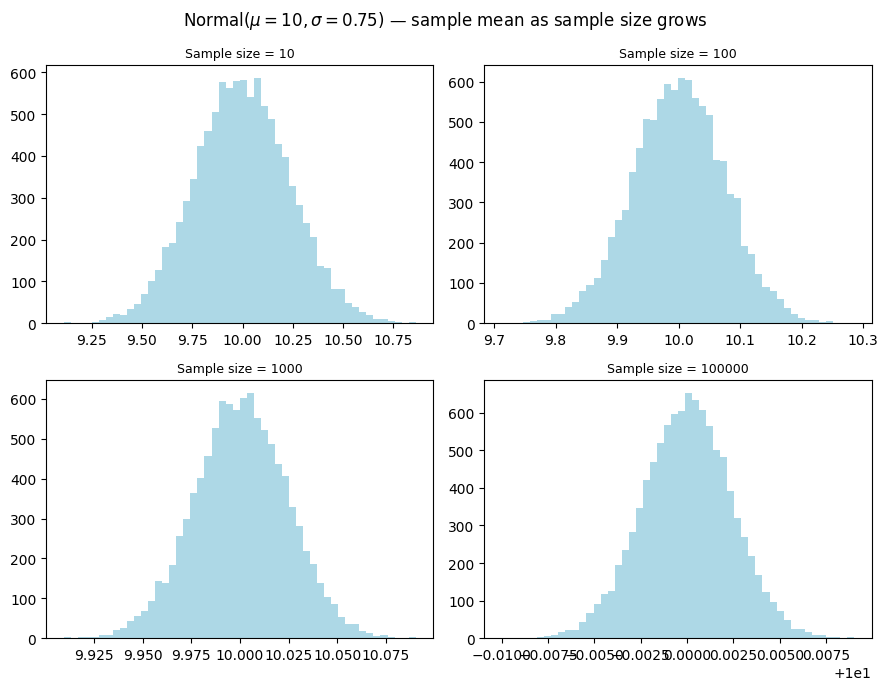

In [119]:
clt_grid_by_size(lambda n: rng.normal(loc=10, scale=0.75, size=n), sample_sizes, n_means_fixed, "lightblue",
                 r"Normal($\mu=10, \sigma=0.75$) — sample mean as sample size grows")

**What we see.** As the sample size $N$ increases, the sample means **concentrate ever more tightly** around the true mean — the visual face of the standard-error law $\sigma_{\bar{x}} = \sigma/\sqrt{N}$ from R2.9. More repetitions reveal the *shape* of the sampling distribution; a larger sample size controls its *spread*.

> **Central Limit Theorem.** In probability theory, the central limit theorem (CLT) establishes that, in many situations, when independent random variables are added, their properly normalized sum tends toward a Normal distribution — informally, a bell curve — *even if the original variables themselves are not normally distributed*. It is a key result because it lets statistical methods built for the Normal distribution apply to a huge range of problems involving other distributions. *(Source: Central Limit Theorem, English Wikipedia.)*

### Does it always work? Meet the Cauchy distribution

Strictly speaking, **no** — the CLT has fine print. It needs the underlying distribution to have a **finite mean and variance**. The [Cauchy distribution](https://en.wikipedia.org/wiki/Cauchy_distribution) has *neither*: its tails are so heavy that both are undefined. Watch what happens when we sum Cauchy draws exactly as we summed the others — the **sum of 1000 draws**, collected 100, 1,000, 10,000, and 100,000 times:

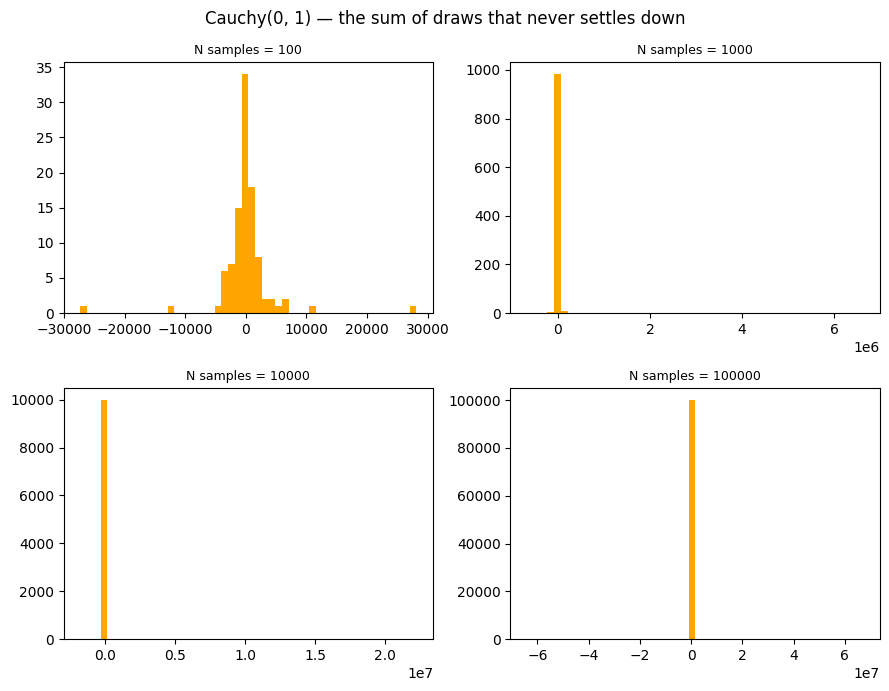

In [120]:
# Cauchy(location=0, scale=1): heavy-tailed, with UNDEFINED mean and variance.
# We sum 1000 draws at a time (as in the R original) and vary how many such sums we collect.
cauchy_counts = [100, 1000, 10000, 100000]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, n_sums in zip(axes.ravel(), cauchy_counts):
    # rng.standard_cauchy is location=0, scale=1 — the standard Cauchy.
    cauchy_sums = np.array([rng.standard_cauchy(size=1000).sum() for _ in range(n_sums)])
    ax.hist(cauchy_sums, bins=50, color="orange")
    ax.set_title(f"N samples = {n_sums}", fontsize=9)
fig.suptitle("Cauchy(0, 1) — the sum of draws that never settles down")
fig.tight_layout()
plt.show()

**What we see.** Nothing like a bell curve. However many samples we take, the histogram stays hostage to a handful of gigantic outliers — the axis range explodes into the thousands or millions while almost all the mass collapses into a single central spike. Adding more data does **not** tame it, because there is no finite mean for the sums to converge *to*. The Cauchy is the standard counterexample that keeps us honest: the CLT is powerful but **conditional** on assumptions worth checking. (The Cauchy density is also known, charmingly, as the [Witch of Agnesi](https://en.wikipedia.org/wiki/Witch_of_Agnesi).)

**Why this closes the course's statistics arc.** With that caveat noted, the CLT is precisely the fact that makes Sessions 01–03 legitimate. When Session 01 reported a mean hourly demand with a confidence interval, when Session 02 bootstrapped a risk rate, when Session 03 ran a t-test — each one leaned, knowingly or not, on the CLT: the sample mean is approximately Normal, its spread is $\sigma/\sqrt{N}$, and that is what lets us attach honest uncertainty to a number computed from a mere sample. Everything the analyst says about *confidence* rests on the two sections you just worked through — and, as the Cauchy reminds us, on the assumptions holding.

<hr>

![](../_img/DK_Logo_White_150.png)

DataKolektiv, 2026.

[hello@datakolektiv.com](mailto:hello@datakolektiv.com)

<font size=1>License: [GPLv3](../LICENSE). This Notebook is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version. This Notebook is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.</font>